# 0.0 - Imports

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import inflection
import math
import datetime
import xgboost as xgb
import random
import pickle

from pathlib import Path
from IPython.display import Image
from tabulate import tabulate
from scipy import stats as ss
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy

### 0.1 - Helper Functions

In [2]:
pd.set_option('display.max_columns', None)

def cramer_v(x,y):
    cm = pd.crosstab(x,y).to_numpy()
    n = cm.sum()
    r, k = cm.shape
    
    chi2 = ss.chi2_contingency(cm)[0]
    chi2corr = chi2 - max(0, (k-1)*(r-1)/(n-1))
    
    kcorr = k - (k-1)**2/(n-1)
    rcorr = r - (r-1)**2/(n-1)

    return np.sqrt((chi2corr/n) / (min(kcorr-1,r-1)))

def mean_absolute_percentage_error(y, yhat):
    return np.mean(np.abs((y-yhat)/y))

def mean_percentage_error(y, yhat):
    return np.mean((y-yhat)/y)

def ml_error(model_name, y, yhat):
    mae  = mean_absolute_error(y, yhat)
    mape = mean_absolute_percentage_error(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    return pd.DataFrame({'Model Name': model_name, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse}, index=[0])

def cross_validation(x_training, kfold, model_name, model, verbose=False,
                     robust_cols=None, minmax_cols=None):
    mae_list, mape_list, rmse_list = [], [], []

    for k in reversed(range(1, kfold + 1)):
        if verbose:
            print(f'\nKFold Number: {k}')

        validation_start_date = x_training['date'].max() - datetime.timedelta(days=k*6*7)
        validation_end_date   = x_training['date'].max() - datetime.timedelta(days=(k-1)*6*7)

        training   = x_training[x_training['date'] < validation_start_date]
        validation = x_training[(x_training['date'] >= validation_start_date) &
                                  (x_training['date'] <= validation_end_date)]

        xtraining   = training.drop(['date', 'sales'], axis=1).copy()
        ytraning    = np.log1p(training['sales'])
        xvalidation = validation.drop(['date', 'sales'], axis=1).copy()
        yvalidation = np.log1p(validation['sales'])

        # Re-fit scalers por fold para evitar vazamento de dados
        if robust_cols:
            _rs = RobustScaler()
            xtraining[robust_cols]   = _rs.fit_transform(xtraining[robust_cols])
            xvalidation[robust_cols] = _rs.transform(xvalidation[robust_cols])
        if minmax_cols:
            _mms = MinMaxScaler()
            xtraining[minmax_cols]   = _mms.fit_transform(xtraining[minmax_cols])
            xvalidation[minmax_cols] = _mms.transform(xvalidation[minmax_cols])

        m    = model.fit(xtraining, ytraning)
        yhat = m.predict(xvalidation)

        m_result = ml_error(model_name, np.expm1(yvalidation), np.expm1(yhat))
        mae_list.append(m_result['MAE'])
        mape_list.append(m_result['MAPE'])
        rmse_list.append(m_result['RMSE'])

    return pd.DataFrame({
        'Model Name':  model_name,
        'MAE CV MEAN':  np.round(np.mean(mae_list), 2).astype(str) + ' +/- ' + np.round(np.std(mae_list), 2).astype(str),
        'MAPE CV MEAN': np.round(np.mean(mape_list), 2).astype(str) + ' +/- ' + np.round(np.std(mape_list), 2).astype(str),
        'RMSE CV MEAN': np.round(np.mean(rmse_list), 2).astype(str) + ' +/- ' + np.round(np.std(rmse_list), 2).astype(str),
    }, index=[0])

### 0.2 - Loading Dataset

In [3]:
#Determina a pasta atual e a raiz do projeto
actual_directory = Path.cwd()
main_path = actual_directory.parent

#Direciona para as pastas que os arquivos estão assets/data
train_df = main_path / "assets" / "data" / "train.csv"
store_df = main_path / "assets" / "data" / "store.csv"
test_df = main_path / "assets" / "data" / "test.csv"

#Direciona para a pasta que contem o mapa mental
mindmap = main_path / "assets" / "img" / "mindmap_rossmann.png"

#Carrga os arquvos de vendas (vendas = train.csv e lojas = store.csv)
df_sales_raw = pd.read_csv(train_df, low_memory=False)
df_store_raw = pd.read_csv(store_df, low_memory=False)

#Faz um merge dos dois dataframes
df_raw = pd.merge(df_sales_raw, df_store_raw, how='left', on='Store')

# 1.0 - Descrição dos Dados

### Cópia de Segurança do dataset

In [4]:
df1 = df_raw.copy()

### 1.1 - Rename Columns (snake_case)

In [5]:
cols_old = ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo','StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth','CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek','Promo2SinceYear', 'PromoInterval']

snakecase = lambda x: inflection.underscore( x )

cols_new = list (map( snakecase, cols_old ))

# rename
df1.columns = cols_new

### 1.2 - Data Dimensions

In [6]:
print('Number os Rows: {}'.format(df1.shape[0] ) )
print('Number os Columns: {}'.format(df1.shape[1] ) )

Number os Rows: 1017209
Number os Columns: 18


### 1.3 - Data Types

In [7]:
df1['date'] = pd.to_datetime (df1['date'])
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                             str
dtype: object

### 1.4 - Check NA

In [8]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

### 1.5 - Fillout NA

In [9]:
#competition_distance
df1['competition_distance'] = df1['competition_distance'].apply (lambda x: 200000.0 if math.isnan( x ) else x )

#competition_open_since_month
df1['competition_open_since_month'] = df1.apply (lambda x: x['date'].month if math.isnan(x['competition_open_since_month']) else x['competition_open_since_month'], axis = 1)

#competition_open_since_year
df1['competition_open_since_year'] = df1.apply (lambda x: x['date'].year if math.isnan(x['competition_open_since_year']) else x['competition_open_since_year'], axis = 1)

#promo2_since_week
df1['promo2_since_week'] = df1.apply (lambda x: x['date'].isocalendar().week if math.isnan(x['promo2_since_week']) else x['promo2_since_week'], axis = 1)

#promo2_since_year
df1['promo2_since_year'] = df1.apply (lambda x: x['date'].year if math.isnan(x['promo2_since_year']) else x['promo2_since_year'], axis = 1)

#promo_interval
month_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

df1['promo_interval'] = df1['promo_interval'].fillna('0')

df1['month_map'] = df1['date'].dt.month.map(month_map)

df1['is_promo'] = df1[['promo_interval', 'month_map']].apply(
    lambda x: 0 if x['promo_interval'] == '0'
              else 1 if x['month_map'] in x['promo_interval'].split(',')
              else 0,
    axis=1
)

### 1.6 - Change Types

In [10]:
df1['competition_open_since_month'] = df1['competition_open_since_month'].astype ( int )
df1['competition_open_since_year'] = df1['competition_open_since_year'].astype ( int )
df1['promo2_since_week'] = df1['promo2_since_week'].astype ( int )
df1['promo2_since_year'] = df1['promo2_since_year'].astype ( int )

### 1.7 - Descriptive Statistical

In [11]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64'])

#### 1.7.1 - Numerical Aributtes

In [12]:
# Central Tendency - Media e Mediana
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew kur
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(min)).T
d3 = pd.DataFrame(num_attributes.apply(max)).T
d4 = pd.DataFrame(num_attributes.apply (lambda x: x.max()-x.min())).T   # <- Range
d5 = pd.DataFrame(num_attributes.apply (lambda x: x.skew())).T          # <- Skew
d6 = pd.DataFrame(num_attributes.apply (lambda x: x.kurtosis())).T      # <- Kurtosis

#Concatenate
m = pd.concat([d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,store,1.0,1115.0,1114.0,558.429727,558.0,321.908493,-0.000955,-1.200524
1,day_of_week,1.0,7.0,6.0,3.998341,4.0,1.997390,0.001593,-1.246873
2,sales,0.0,41551.0,41551.0,5773.818972,5744.0,3849.924283,0.641460,1.778375
3,customers,0.0,7388.0,7388.0,633.145946,609.0,464.411506,1.598650,7.091773
4,open,0.0,1.0,1.0,0.830107,1.0,0.375539,-1.758045,1.090723
5,promo,0.0,1.0,1.0,0.381515,0.0,0.485758,0.487838,-1.762018
6,school_holiday,0.0,1.0,1.0,0.178647,0.0,0.383056,1.677842,0.815154
7,competition_distance,20.0,200000.0,199980.0,5935.442677,2330.0,12547.646829,10.242344,147.789712
8,competition_open_since_month,1.0,12.0,11.0,6.786849,7.0,3.311085,-0.042076,-1.232607
9,competition_open_since_year,1900.0,2015.0,115.0,2010.324840,2012.0,5.515591,-7.235657,124.071304


#### 1.7.2 - Categorical Aributtes

In [13]:
cat_attributes.apply(lambda x: x.unique().shape[0])

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

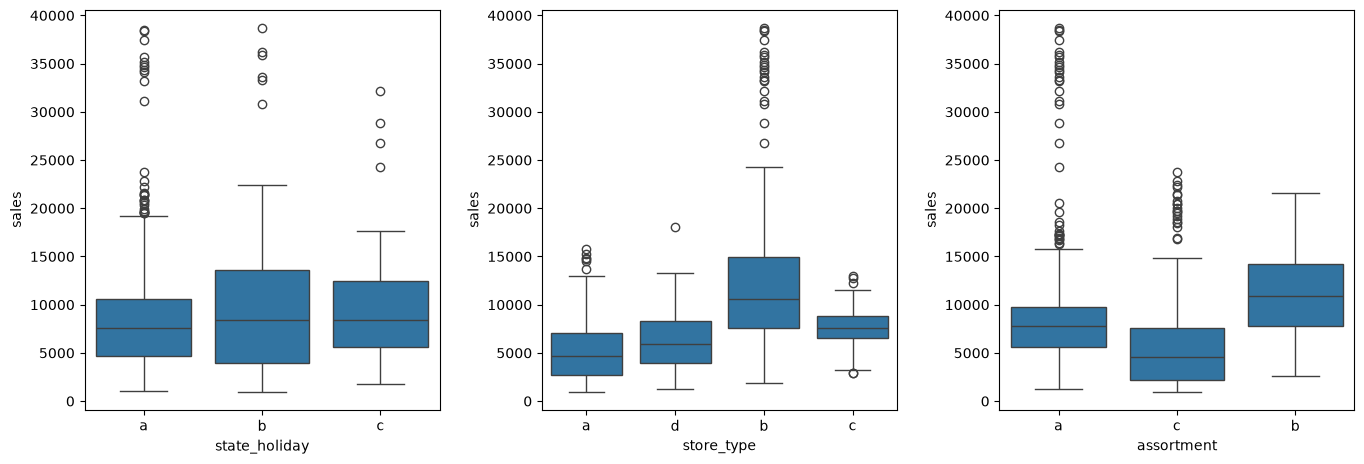

In [14]:
aux1 = df1[(df1['state_holiday'] !='0') & (df1['sales'] > 0)]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='state_holiday', y='sales', data=aux1)

plt.subplot(1, 3, 2)
sns.boxplot(x='store_type', y='sales', data=aux1)

plt.subplot(1, 3, 3)
sns.boxplot(x='assortment', y='sales', data=aux1)

plt.tight_layout(pad=2.0)
plt.show()

# 2.0 - Feature Engineering

In [15]:
df2 = df1.copy()

### 2.1 - Criação de Hipoteses (Alavancas)

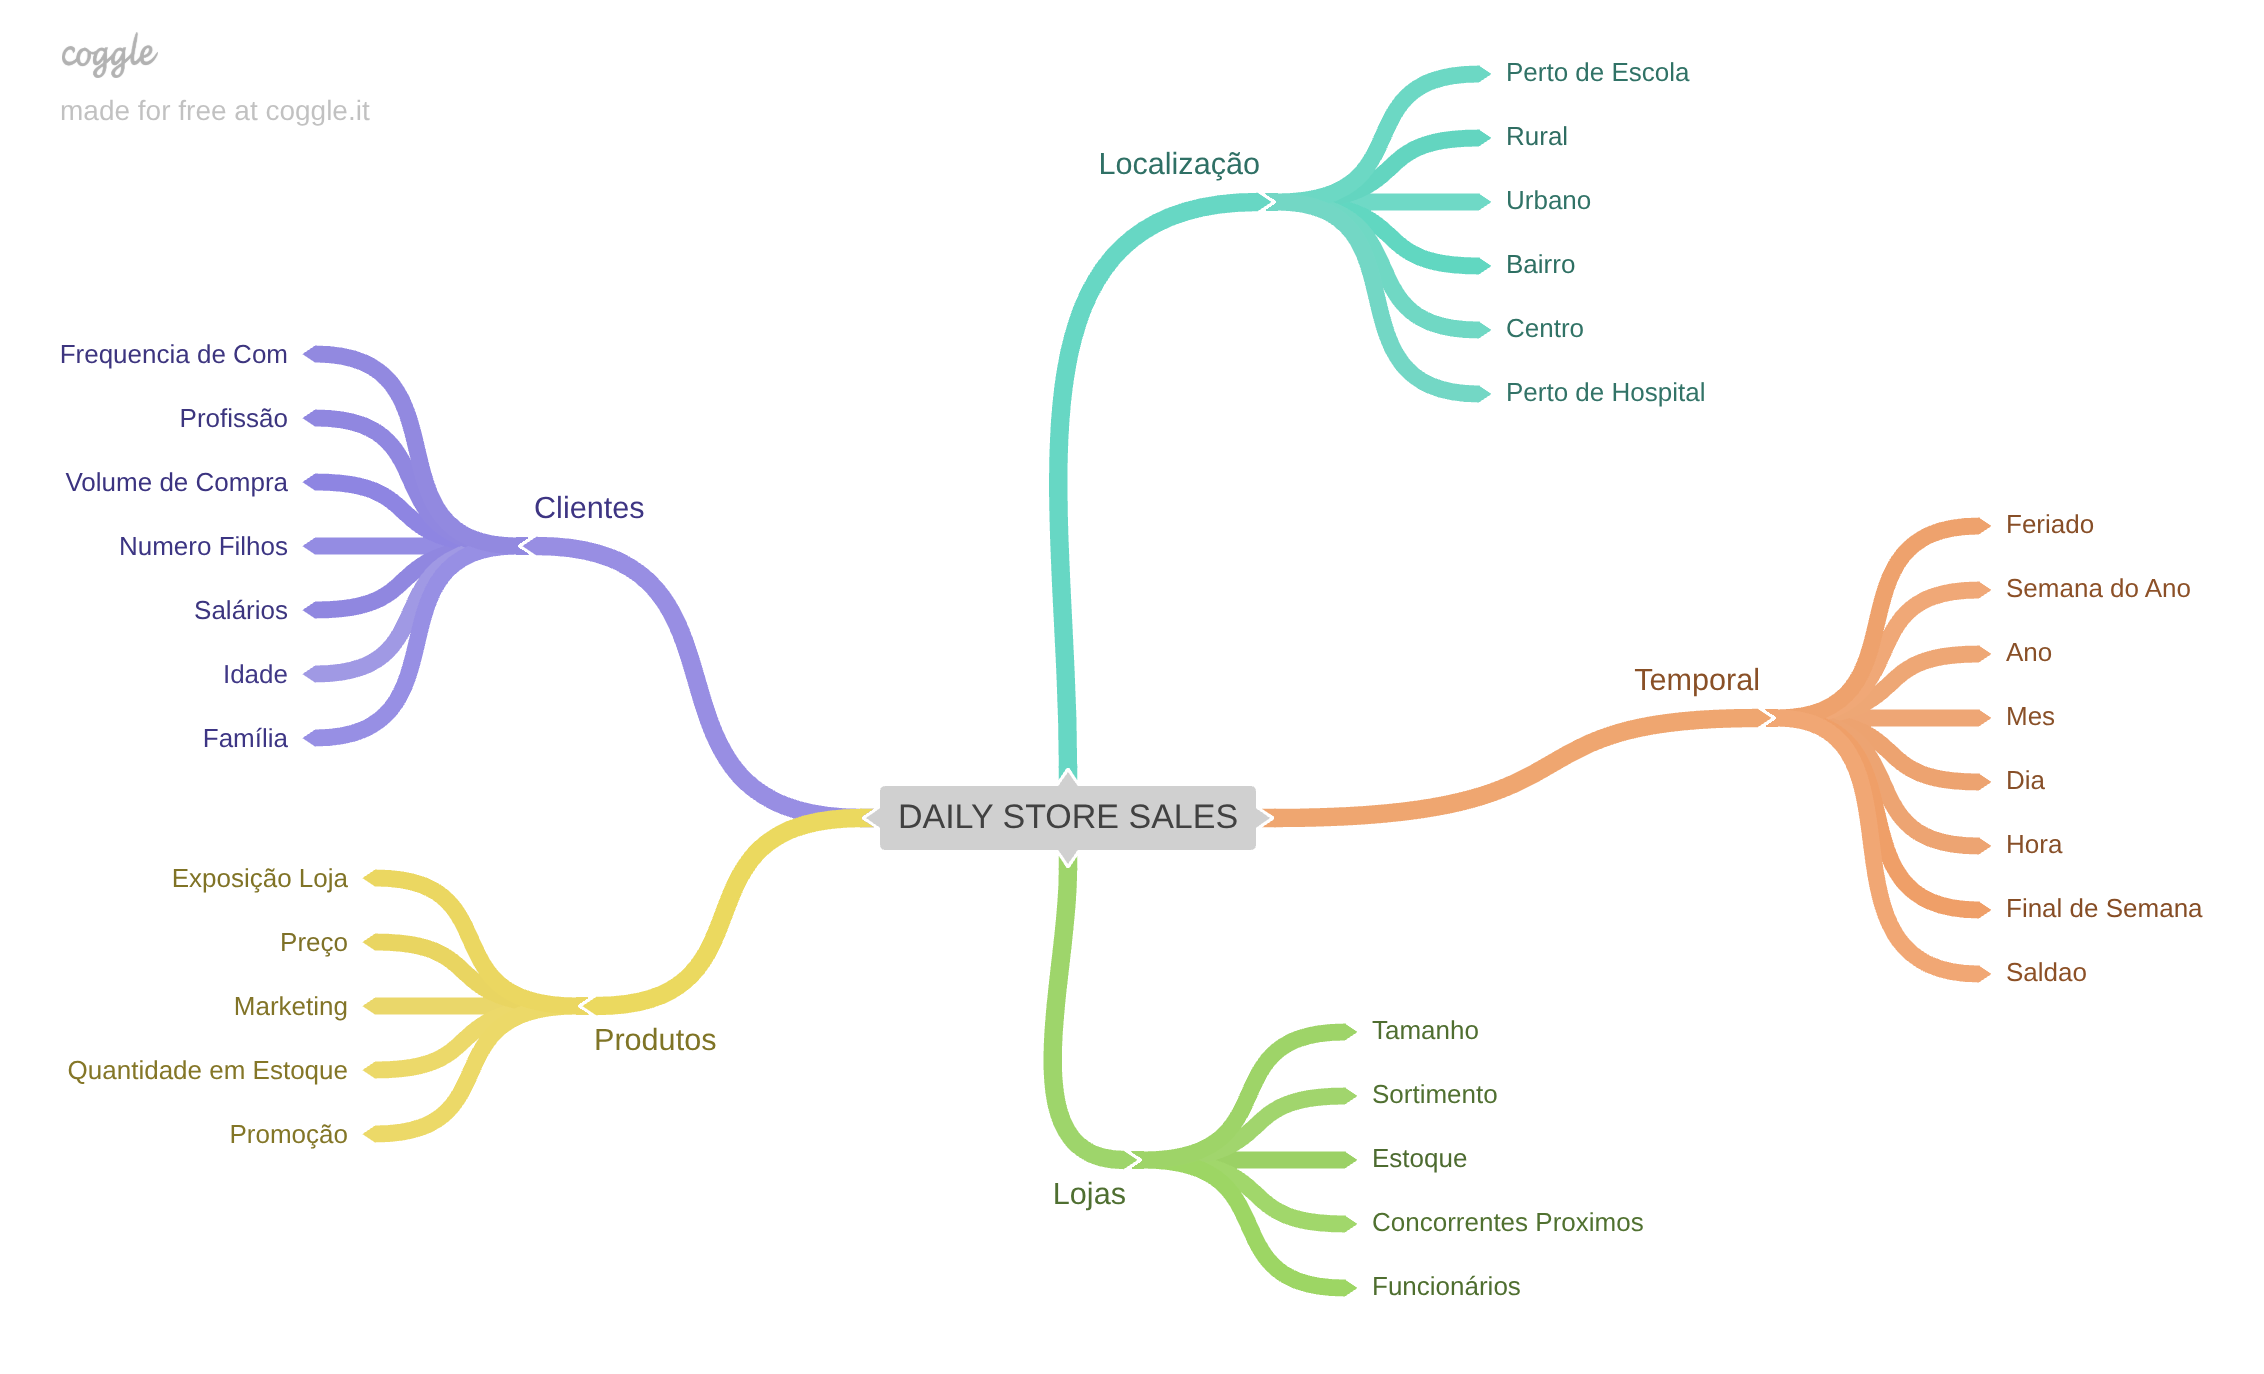

In [16]:
Image (mindmap)

#### 2.1.1 - Hipoteses Loja

**1.** - Lojas com maior quadro de funcionários deveriam vender mais

**2.** - Lojas com maior estoque deveriam vender mais

**3.** - Lojas com maior porte deveriam vender mais

**4.** - Lojas com menor porte deveriam vender menos

**5.** - Lojas com maior sortimento deveriam vender mais

#### 2.1.2 - Hipoteses Produto

**1.** - Lojas que investem mais em Marketing deveriam vender mais

**2.** - Lojas que expoem mais os produtos nas vitrines deveriam vender mais

**3.** - Lojas que tem preços menores nos produtos deveriam vender mais

**4.** - Lojas que tem preços menores por mais tempo nos produtos deveriam vender mais

#### 2.1.3 - Hipoteses Tempo

**1.** - Lojas que tem mais feriados deveriam vender menos (fechada ou fluxo)

**2.** - Lojas que abrem nos primeiros seis meses deveriam vender mais

**3.** - Lojas que abrem nos finais de semana deveriam vender mais

### 2.2 - Lista Final de Hipoteses

**1.** Lojas com maior sortimento deveriam vender mais

**2.** Lojas com competidores mais proximos deveriam vender menos

**3.** Lojas com competidores a mais tempo deveriam vender mais


**4.** Lojas com promoções ativas por mais tempo deveriam vender mais

**5.** Lojas com mais dias de promoção deveriam vender mais

**6.** Lojas com mais promoções deveriam vender mais

**7.** Lojas abertas durante o feriado de Natal deveriam vender mais

**8.** Lojas deveriam vender mais ao longo do tempo

**9.** Lojas deveriam vender mais no segundo semestre do ano

**10.** Lojas deveriam vender mais depois do dia 10 de cada mês

**11.** Lojas deveriam vender menos aos finais de semana

**12.** Lojas deveriam vender menos durante os feriados escolares

### 2.3 - Feature Engineering

In [17]:
# year
df2['year'] = df2['date'].dt.year

# month
df2['month'] = df2['date'].dt.month

# day
df2['day'] = df2['date'].dt.day

# week of year
df2['week_of_year'] = df2['date'].dt.isocalendar().week

#year week
df2['year_week'] = df2['date'].dt.strftime('%Y-%W')

# competition since
df2['competition_since'] = df2.apply(lambda x: datetime.datetime(year=x['competition_open_since_year'], month=x['competition_open_since_month'], day=1), axis=1)
df2['competition_time_month'] = ((df2['date'] - df2['competition_since']) / 30).apply(lambda x: x.days).astype(int)

# promo since
df2['promo_since'] = df2['promo2_since_year'].astype(str) + '-' + df2['promo2_since_week'].astype(str)
df2['promo_since'] = df2['promo_since'].apply(lambda x: datetime.datetime.strptime(x + '-1', '%Y-%W-%w')- datetime.timedelta(days=7))
df2['promo_time_week'] = ((df2['date'] - df2['promo_since']) / 7).apply(lambda x: x.days).astype(int)

# assortment
df2['assortment'] = df2['assortment'].apply(lambda x: 'basic' if x == 'a' else 'extra' if x == 'b' else 'extended')

# state holiday
df2['state_holiday'] = df2['state_holiday'].apply(lambda x: 'public_holiday' if x == 'a' else 'easter_holiday' if x == 'b' else 'christmas' if x == 'c' else 'regular_day')

# 3.0 - Filtragem de Variaveis

In [18]:
df3 = df2.copy()

In [19]:
df3.head()

,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,promo_interval,month_map,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,555,1,1,regular_day,1,c,basic,1270.0,9,2008,0,31,2015,0,Jul,0,2015,7,31,31,2015-30,2008-09-01,84,2015-07-27,0
1,2,5,2015-07-31,6064,625,1,1,regular_day,1,a,basic,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct",Jul,1,2015,7,31,31,2015-30,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,821,1,1,regular_day,1,a,basic,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct",Jul,1,2015,7,31,31,2015-30,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1498,1,1,regular_day,1,c,extended,620.0,9,2009,0,31,2015,0,Jul,0,2015,7,31,31,2015-30,2009-09-01,71,2015-07-27,0
4,5,5,2015-07-31,4822,559,1,1,regular_day,1,a,basic,29910.0,4,2015,0,31,2015,0,Jul,0,2015,7,31,31,2015-30,2015-04-01,4,2015-07-27,0


### 3.1 - Filtragem das Linhas

In [20]:
df3 = df3[(df3['open'] != 0) & (df3['sales'] > 0)]

### 3.2 - Seleção das Colunas

In [21]:
cols_drop = ['customers', 'open', 'promo_interval', 'month_map']
df3 = df3.drop(cols_drop, axis=1)

# 4.0 - Analise Exploratória de Dados (EDA)

In [22]:
df4 = df3.copy()

### 4.1 - Analise Univariada

#### 4.1.1 - Response Variable

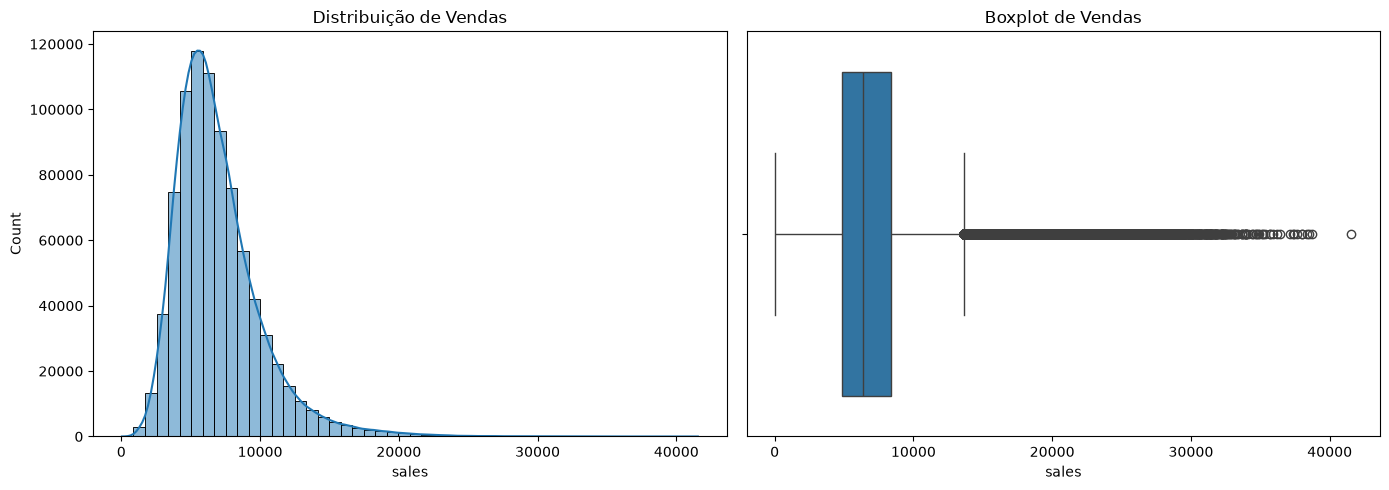

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df4['sales'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Vendas')

sns.boxplot(x=df4['sales'], ax=axes[1])
axes[1].set_title('Boxplot de Vendas')

plt.tight_layout()
plt.show()

#### 4.1.2 - Numerical Variable

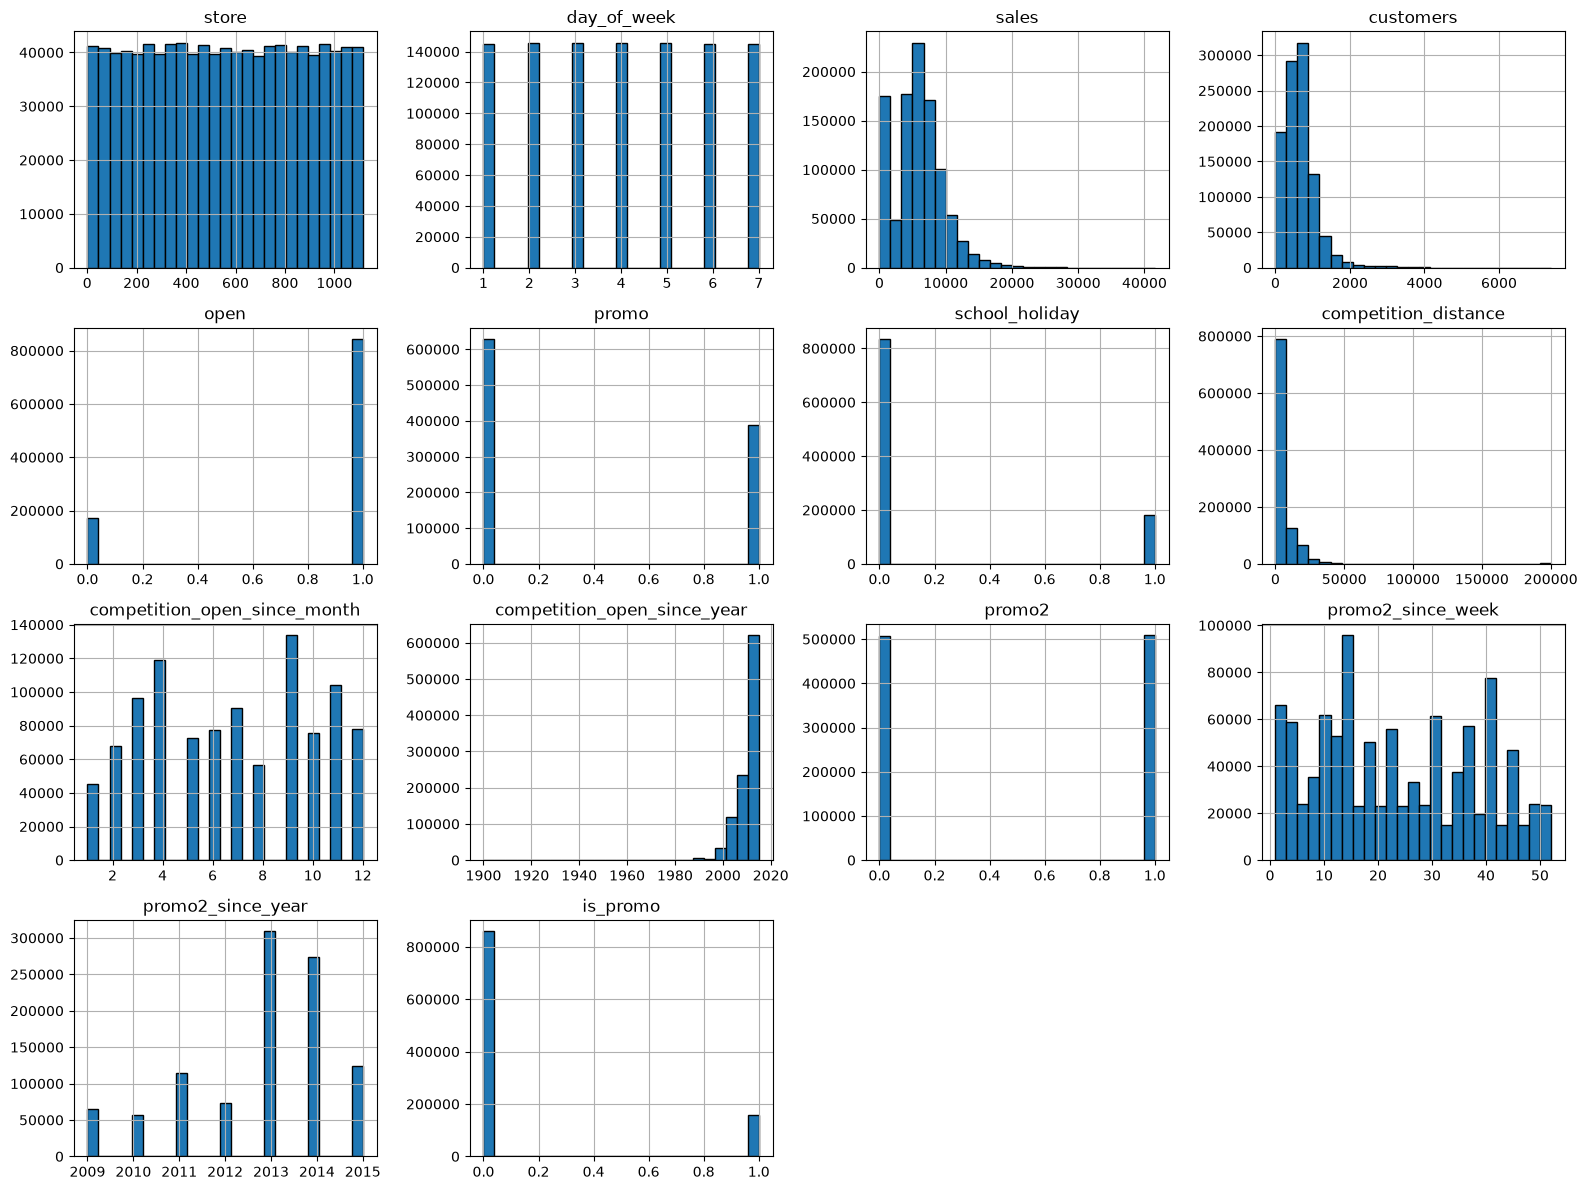

In [24]:
num_attributes.hist(figsize=(16, 12), bins=25, edgecolor='black')
plt.tight_layout()
plt.show()

#### 4.1.3 - Categorical Variable

In [25]:
df4['assortment'].drop_duplicates()

0         basic
3      extended
258       extra
Name: assortment, dtype: str

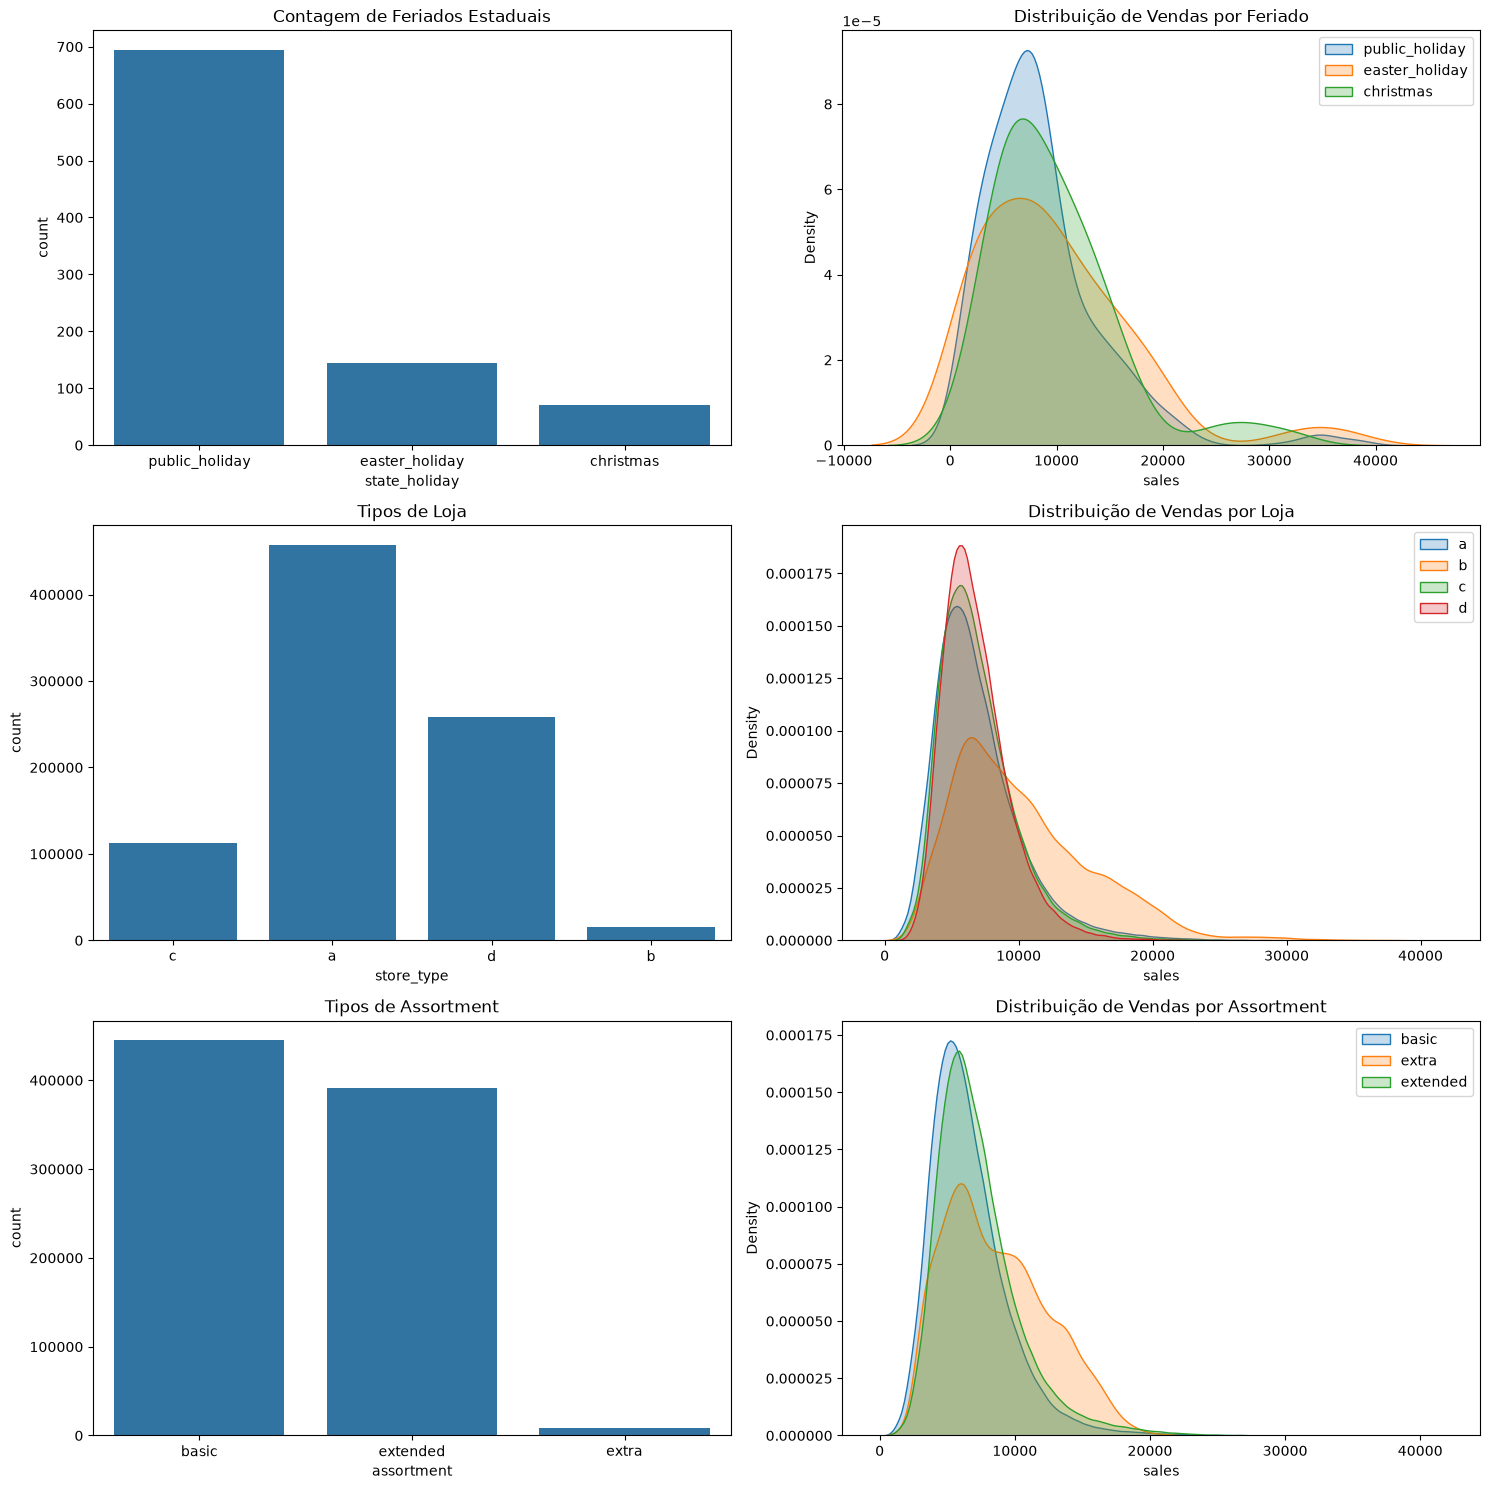

In [26]:
# Criando a matriz de gráficos 3x2
fig, ax = plt.subplots(3, 2, figsize=(15, 15))

# ==========================================
# 1. Ajuste dos Feriados (state_holiday)
# ==========================================
a = df4[df4['state_holiday'] != 'regular_day']
sns.countplot(data=a, x='state_holiday', ax=ax[0, 0])
ax[0, 0].set_title('Contagem de Feriados Estaduais')

sns.kdeplot(df4[df4['state_holiday'] == 'public_holiday']['sales'], label='public_holiday', fill=True, ax=ax[0, 1])
sns.kdeplot(df4[df4['state_holiday'] == 'easter_holiday']['sales'], label='easter_holiday', fill=True, ax=ax[0, 1])
sns.kdeplot(df4[df4['state_holiday'] == 'christmas']['sales'], label='christmas', fill=True, ax=ax[0, 1])

ax[0, 1].set_title('Distribuição de Vendas por Feriado')
ax[0, 1].legend()

# ==========================================
# 2. Ajuste dos Tipos de Loja (store_type)
# ==========================================
sns.countplot(data=df4, x='store_type', ax=ax[1, 0]) 
ax[1, 0].set_title('Tipos de Loja')

sns.kdeplot(df4[df4['store_type'] == 'a']['sales'], label='a', fill=True, ax=ax[1, 1])
sns.kdeplot(df4[df4['store_type'] == 'b']['sales'], label='b', fill=True, ax=ax[1, 1])
sns.kdeplot(df4[df4['store_type'] == 'c']['sales'], label='c', fill=True, ax=ax[1, 1])
sns.kdeplot(df4[df4['store_type'] == 'd']['sales'], label='d', fill=True, ax=ax[1, 1])

ax[1, 1].set_title('Distribuição de Vendas por Loja')
ax[1, 1].legend()

# ==========================================
# 3. Ajuste dos Tipos de Assortment (Assortment)
# ==========================================
sns.countplot(data=df4, x='assortment', ax=ax[2, 0]) 
ax[2, 0].set_title('Tipos de Assortment')

sns.kdeplot(df4[df4['assortment'] == 'basic']['sales'], label='basic', fill=True, ax=ax[2, 1])
sns.kdeplot(df4[df4['assortment'] == 'extra']['sales'], label='extra', fill=True, ax=ax[2, 1])
sns.kdeplot(df4[df4['assortment'] == 'extended']['sales'], label='extended', fill=True, ax=ax[2, 1])

ax[2, 1].set_title('Distribuição de Vendas por Assortment')
ax[2, 1].legend()


# ==========================================
# 4. Mostra os graficos finais
# ========================================== 
plt.tight_layout()
plt.show()

### 4.2 - Analise Bivariada

#### **H1.** Lojas com maior sortimentos deveriam vender mais

**FALSE** Lojas com MAIORES SORTIMENTOS vendem MENOS

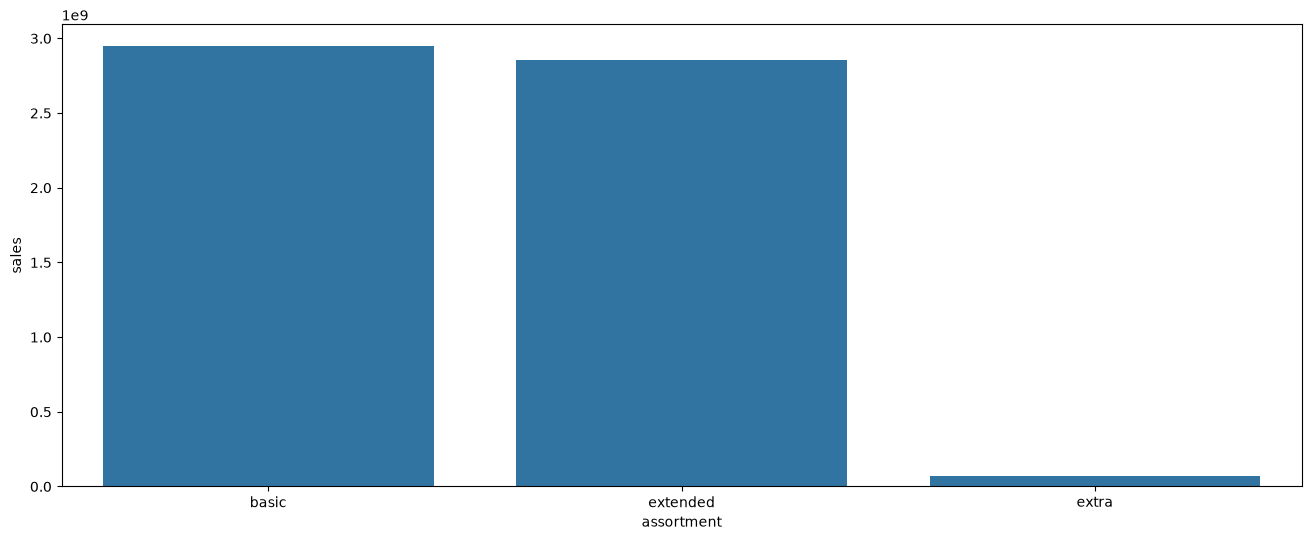

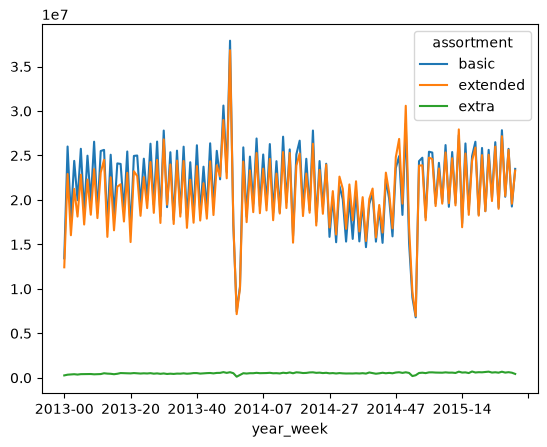

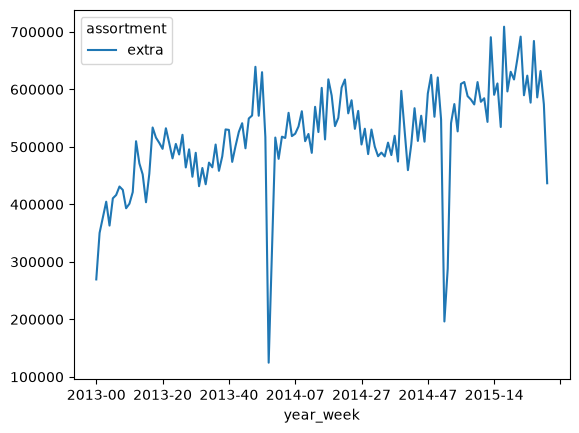

In [27]:
# ==========================================
# 1. Assortment (Assortment) x vendas
# ==========================================

plt.figure(figsize=(16, 6))
aux1 = df4[['assortment', 'sales']].groupby('assortment').sum().reset_index()
sns.barplot(x='assortment', y='sales', data=aux1, errorbar=None);
plt.show()

# ==========================================
# 2. Assortment (Assortment) por semanas do ano x vendas
# ==========================================
aux2 = (df4[['year_week', 'assortment', 'sales']]
        .groupby(['year_week', 'assortment'])
        .sum()
        .reset_index())
aux2.pivot(index='year_week', columns='assortment', values='sales').plot()
plt.show()

# ==========================================
# 3. Assortment (Assortment) = Extra
# ==========================================
aux3 = aux2[aux2['assortment'] == 'extra']
aux3.pivot(index='year_week', columns='assortment', values='sales').plot()
plt.show()

#### **H2.** Lojas com competidores mais proximos deveriam vender menos

**FALSE** Lojas com COMPETIDORES MAIS PROXIMOS vendem MAIS

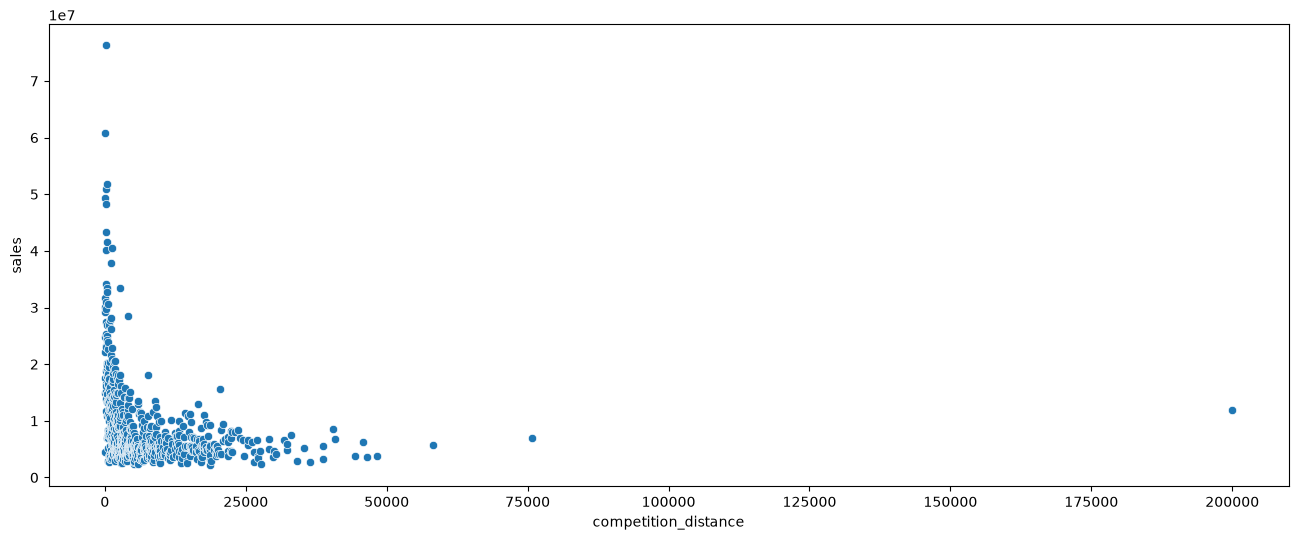

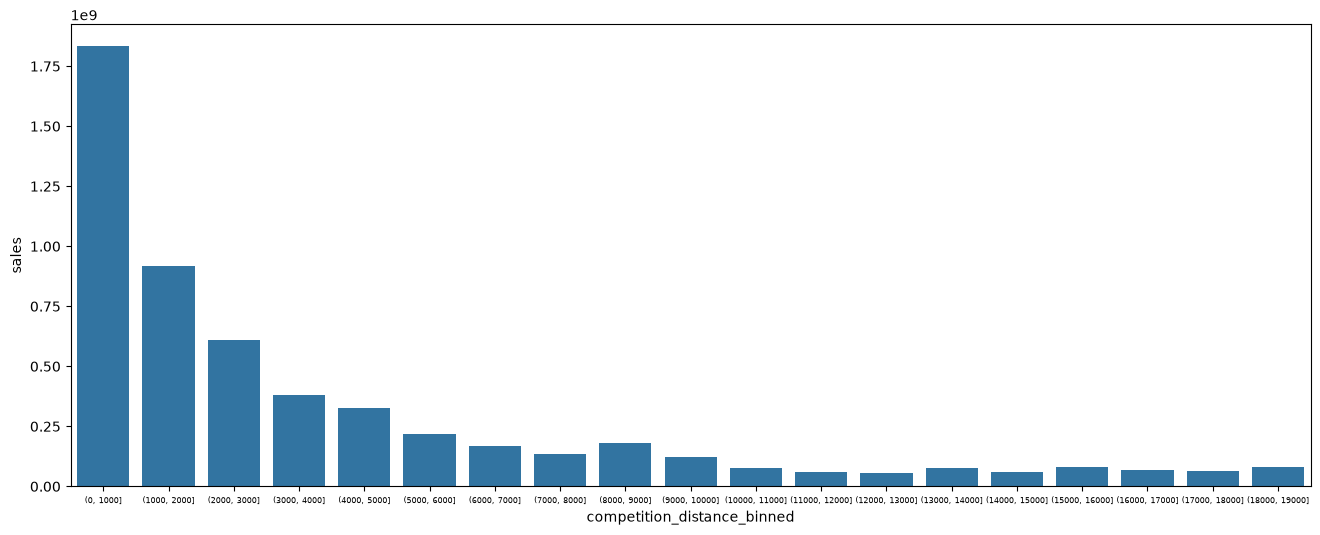

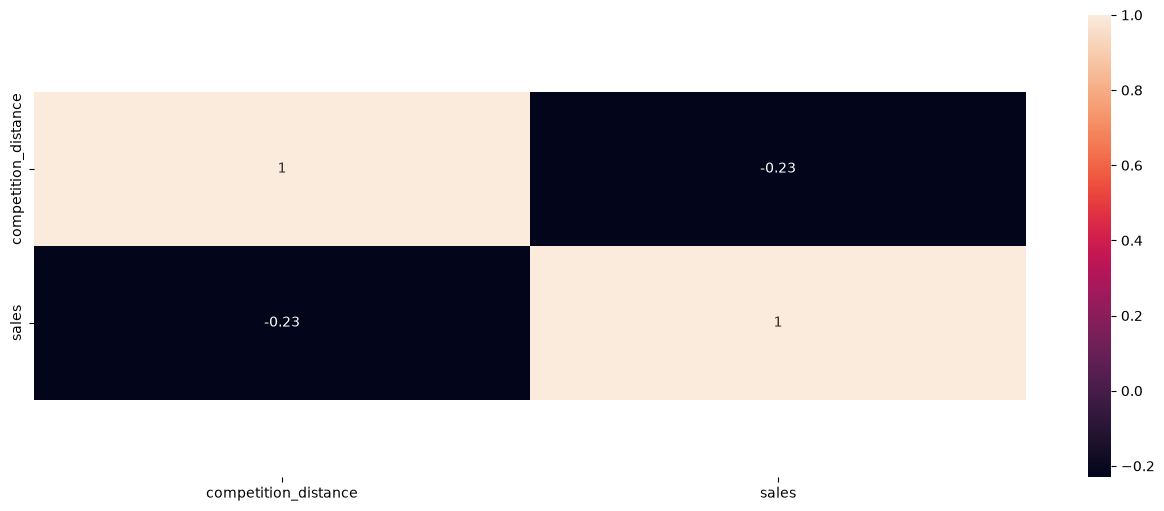

In [28]:
aux1 = df4[['competition_distance', 'sales']].groupby('competition_distance').sum().reset_index()

# ==========================================
# 1. Scatter Plot com as Vendas pela Distancia dos Concorrentes
# ==========================================

plt.figure(figsize=(16, 6))
sns.scatterplot(x = 'competition_distance', y = 'sales', data=aux1)
plt.show()

# ==========================================
# 2. Histograma com as Vendas pela Distancia dos Concorrentes (em Range)
# ==========================================

bins = list(np.arange(0, 20000, 1000))
aux1['competition_distance_binned'] = pd.cut(aux1['competition_distance'], bins=bins)
aux2 = aux1[['competition_distance_binned', 'sales']].groupby('competition_distance_binned').sum().reset_index()

plt.figure(figsize=(16, 6))
sns.barplot(x='competition_distance_binned', y='sales', data=aux2, errorbar=None)
plt.xticks(fontsize=6)
plt.show()

# ==========================================
# 3. Correlação entre Distancia dos Concorrentes e as Vendas
# ==========================================
plt.figure(figsize=(16, 6))
x = sns.heatmap(
    aux1[['competition_distance', 'sales']].corr(method='pearson'),
    annot=True
)
bottom, top = x.get_ylim()
x.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

#### **H3.** Lojas com competidores à mais tempo deveriam vender mais

**FALSE** Lojas com COMPETIDORES A MAIS TEMPO vendem MENOS

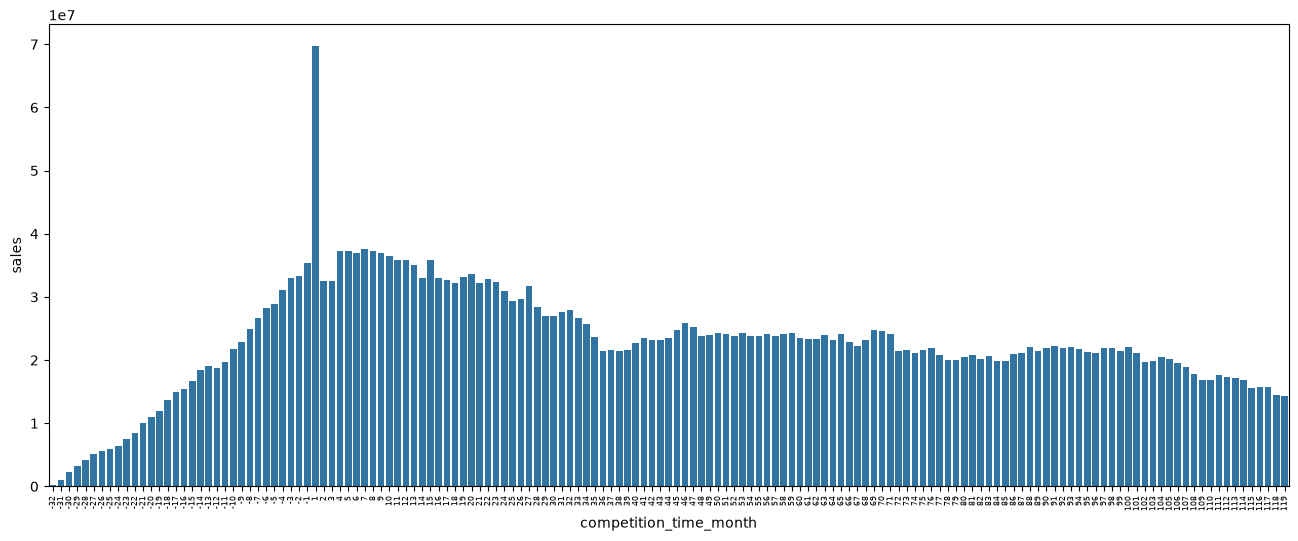

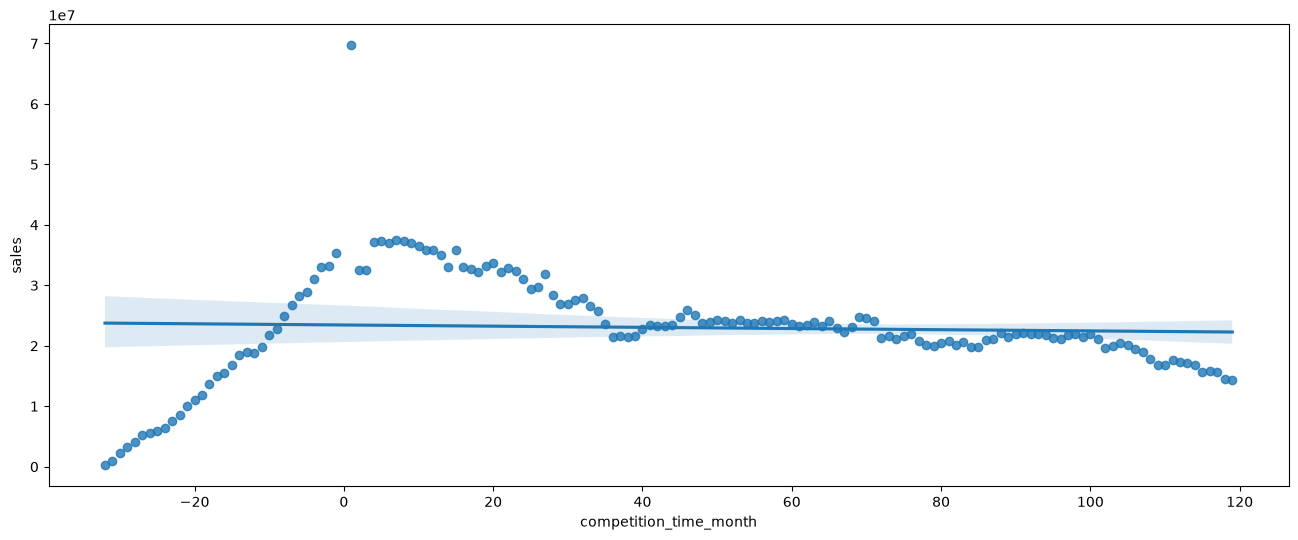

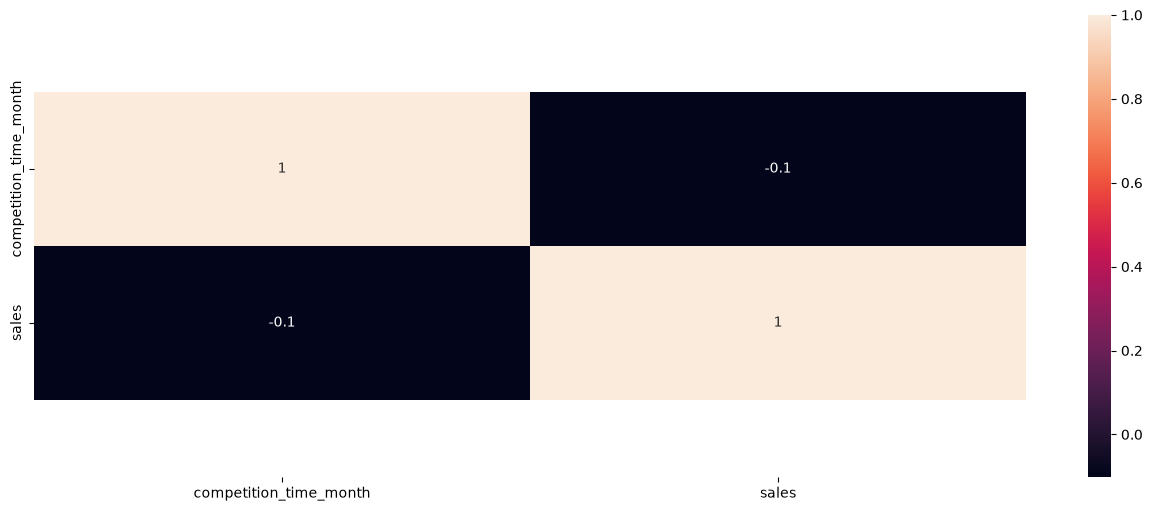

In [29]:
aux1 = df4[['competition_time_month', 'sales']].groupby('competition_time_month').sum().reset_index()
aux2 = aux1[(aux1['competition_time_month'] < 120) & (aux1['competition_time_month'] != 0)]
plt.figure(figsize=(16, 6))
sns.barplot(x='competition_time_month', y='sales', data=aux2)
plt.xticks(fontsize=6, rotation = 90)
plt.show()

plt.figure(figsize=(16, 6))
sns.regplot(x='competition_time_month', y='sales', data=aux2)
plt.show()

plt.figure(figsize=(16, 6))
x = sns.heatmap(
    aux1[['competition_time_month', 'sales']].corr(method='pearson'),
    annot=True
)
bottom, top = x.get_ylim()
x.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

#### **H4.** Lojas com promoções ativas por mais tempo deveriam vender mais

**False** - Lojas com promoções ativas por mais tempo vendem menos, depois de um certo periodo de promoção

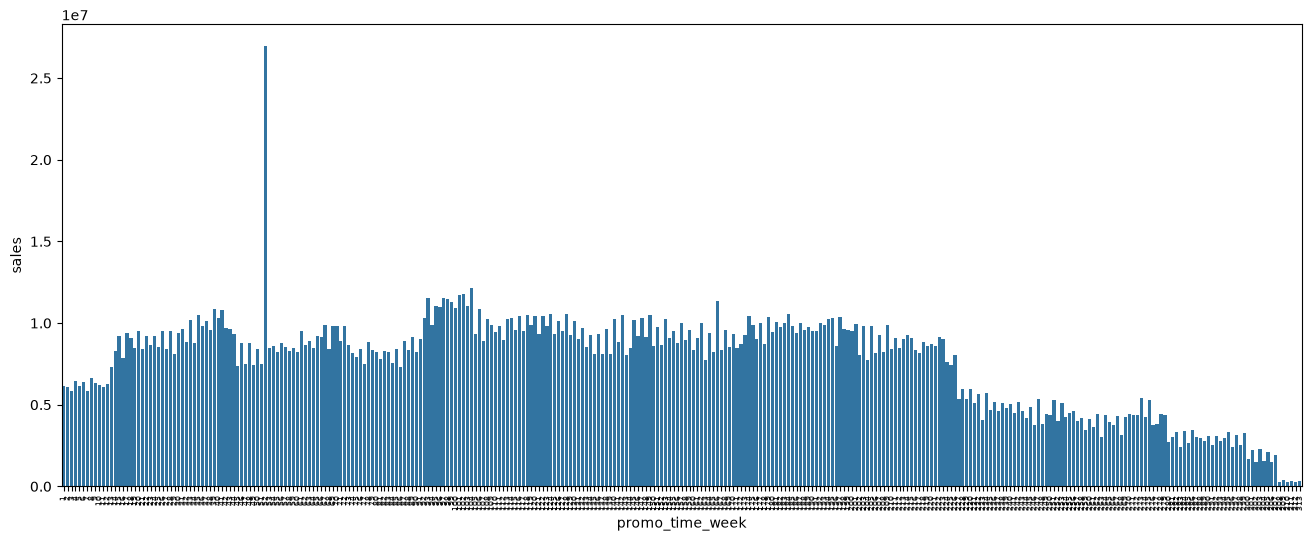

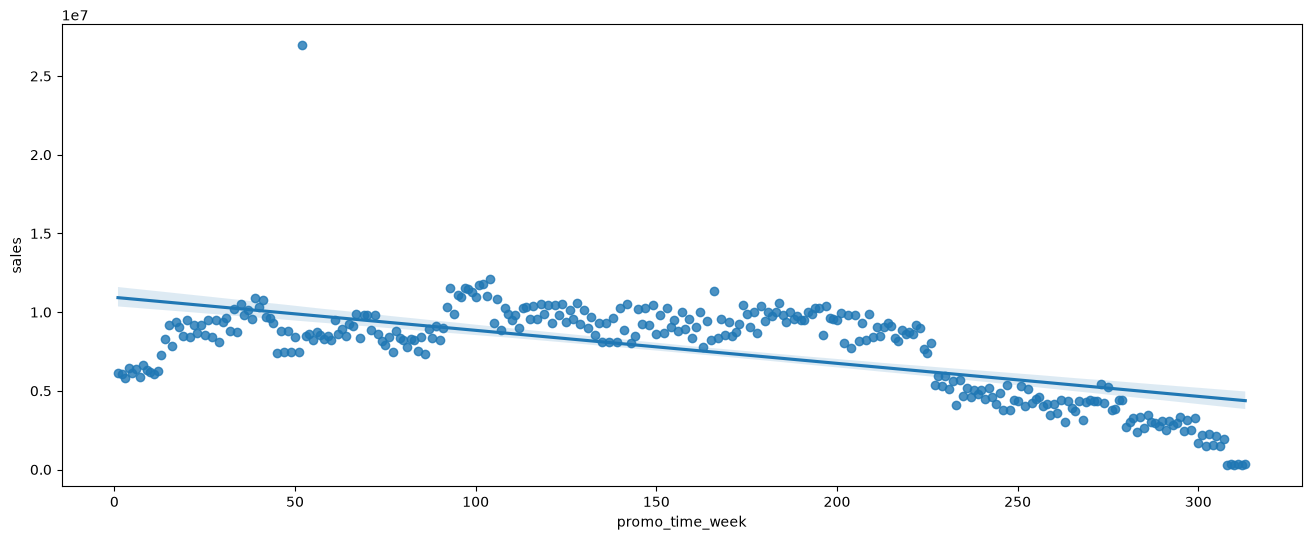

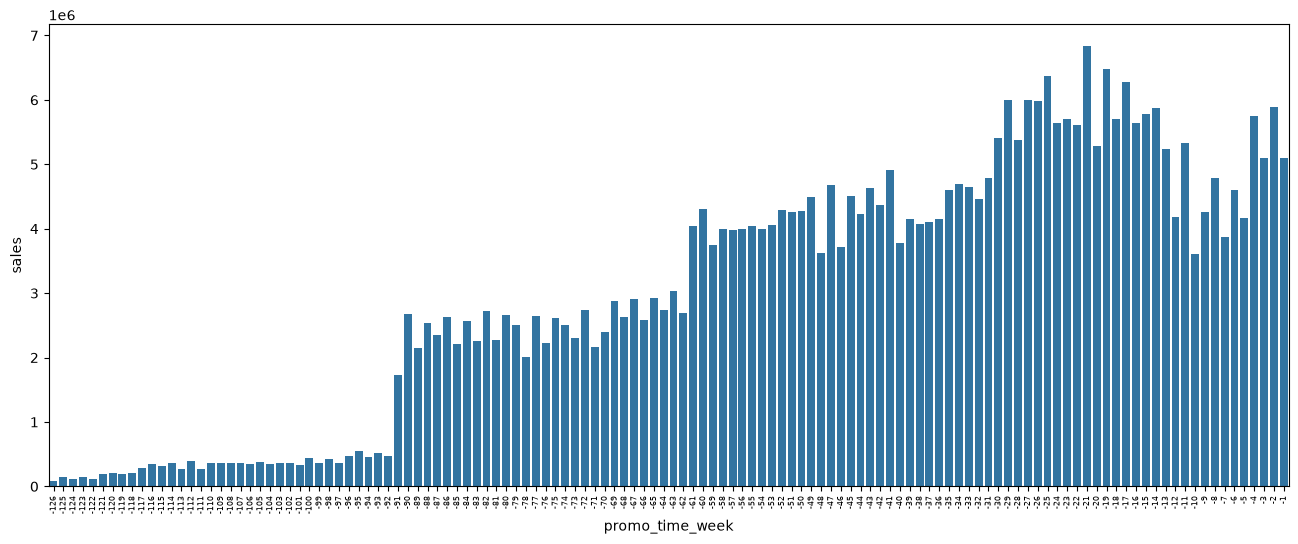

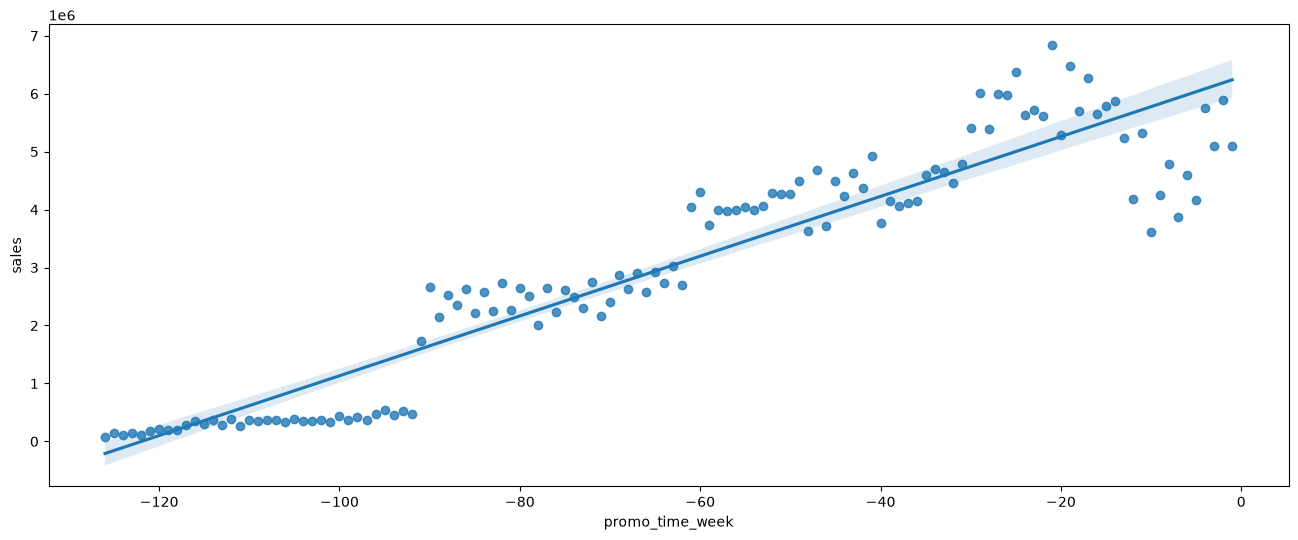

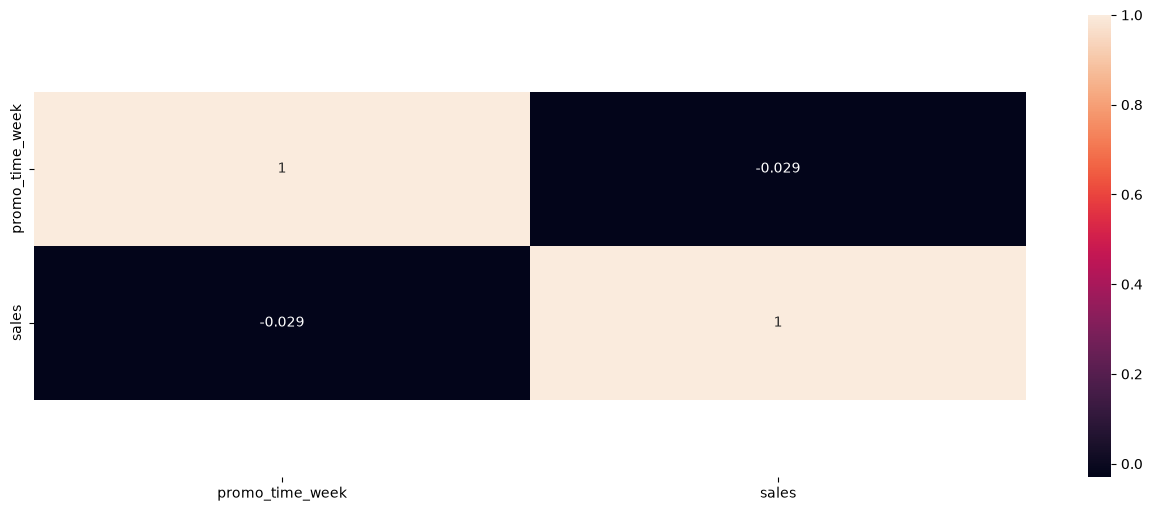

In [30]:
aux1 = df4[['promo_time_week','sales']].groupby('promo_time_week').sum().reset_index()

plt.figure(figsize=(16, 6))
aux2 = aux1[aux1['promo_time_week']> 0] # promo extendido
sns.barplot(x='promo_time_week', y='sales', data=aux2);
plt.xticks(fontsize=6, rotation = 90)
plt.show()

plt.figure(figsize=(16, 6))
sns.regplot(x='promo_time_week', y='sales', data=aux2);
plt.show()

plt.figure(figsize=(16, 6))
aux3 = aux1[aux1['promo_time_week']< 0] # promo regular
sns.barplot(x='promo_time_week', y='sales', data=aux3);
plt.xticks(fontsize=6, rotation = 90)
plt.show()

plt.figure(figsize=(16, 6))
sns.regplot(x='promo_time_week', y='sales', data=aux3);
plt.show()

plt.figure(figsize=(16, 6))
x = sns.heatmap(
    aux1[['promo_time_week', 'sales']].corr(method='pearson'),
    annot=True
)
bottom, top = x.get_ylim()
x.set_ylim(bottom + 0.5, top - 0.5)
plt.show()


#### <s>**H5.** Lojas com mais dias de promoção deveriam vender mais</s>

#### **H6.** Lojas com mais promoções consecutivas deveriam vender mais

**False** - Lojas com mais PROMOÇÕES CONSECUTIVAS vendem MENOS

In [31]:
df4[['promo', 'promo2', 'sales']].groupby(['promo', 'promo2']).sum().reset_index()

,promo,promo2,sales
0,0,0,1482612096
1,0,1,1289362241
2,1,0,1628930532
3,1,1,1472275754


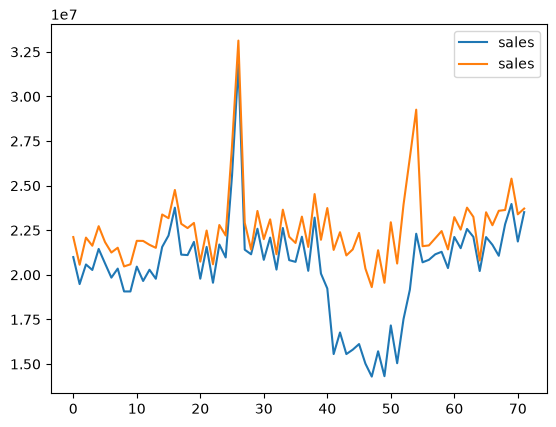

<Figure size 1600x600 with 0 Axes>

In [32]:
aux1 = df4[(df4['promo'] == 1) & (df4['promo2'] == 1)][['year_week', 'sales']].groupby('year_week').sum().reset_index()
ax = aux1.plot()

plt.figure(figsize=(16, 6))
aux2 = df4[(df4['promo'] == 1) & (df4['promo2'] == 0)][['year_week', 'sales']].groupby('year_week').sum().reset_index()
aux2.plot(ax=ax)
plt.show()

ax.legend(labels=['Tradicional & Extendida', 'Extendida'])

#### **H7.** Lojas durante o feriado de Natal deveriam vender mais

**False** - Lojas abertas durante o feriado de natal vendem MENOS

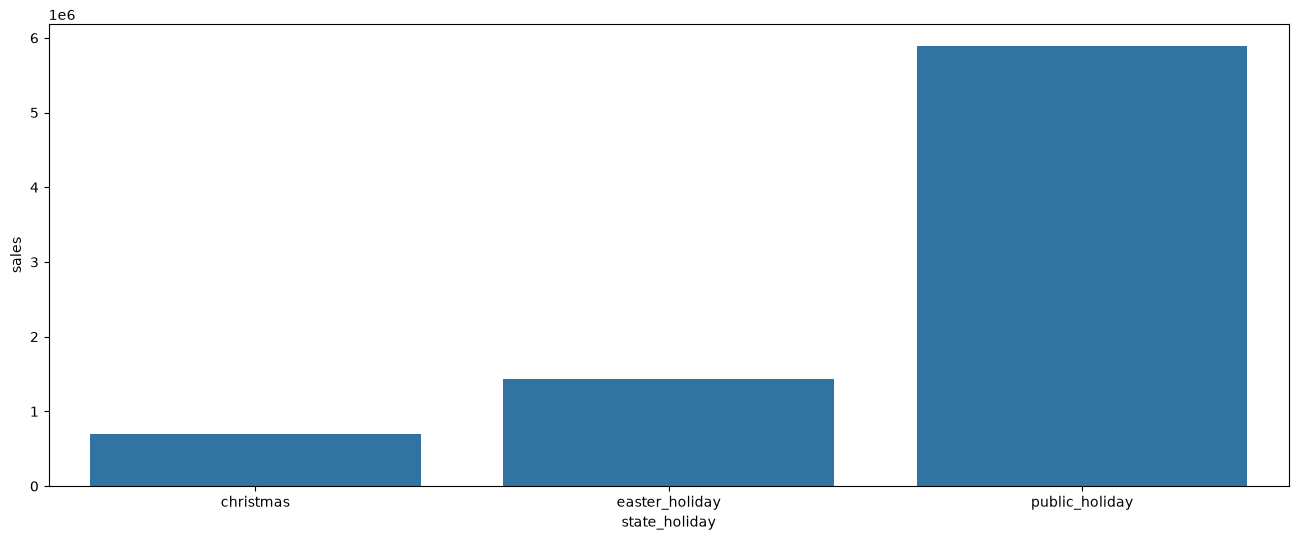

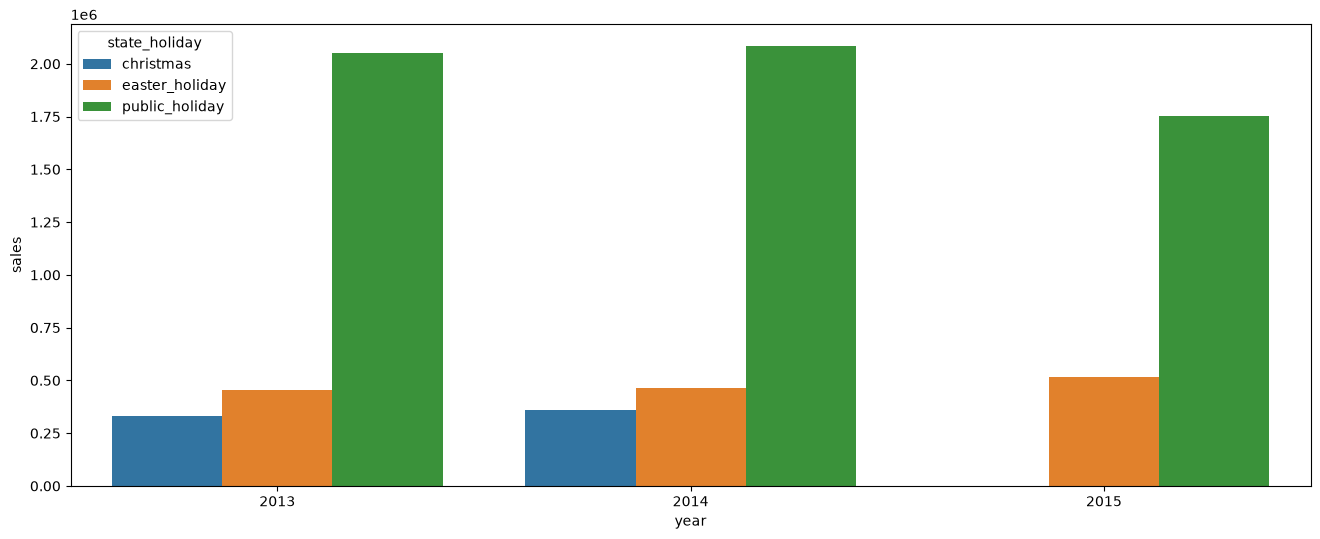

In [33]:
aux = df4[df4['state_holiday'] != 'regular_day']

plt.figure(figsize=(16,6))
aux1 = aux[['state_holiday', 'sales']].groupby('state_holiday').sum().reset_index()
sns.barplot(x='state_holiday', y='sales', data=aux1)
plt.show()

plt.figure(figsize=(16,6))
aux2 = aux[['year','state_holiday','sales']].groupby(['year','state_holiday']).sum().reset_index()
sns.barplot(x='year', y='sales', hue='state_holiday', data=aux2)
plt.show()

#### **H8.** Lojas deveriam vender mais ao longo os anos

**False** - As lojas vendem MENOS a longo dos anos

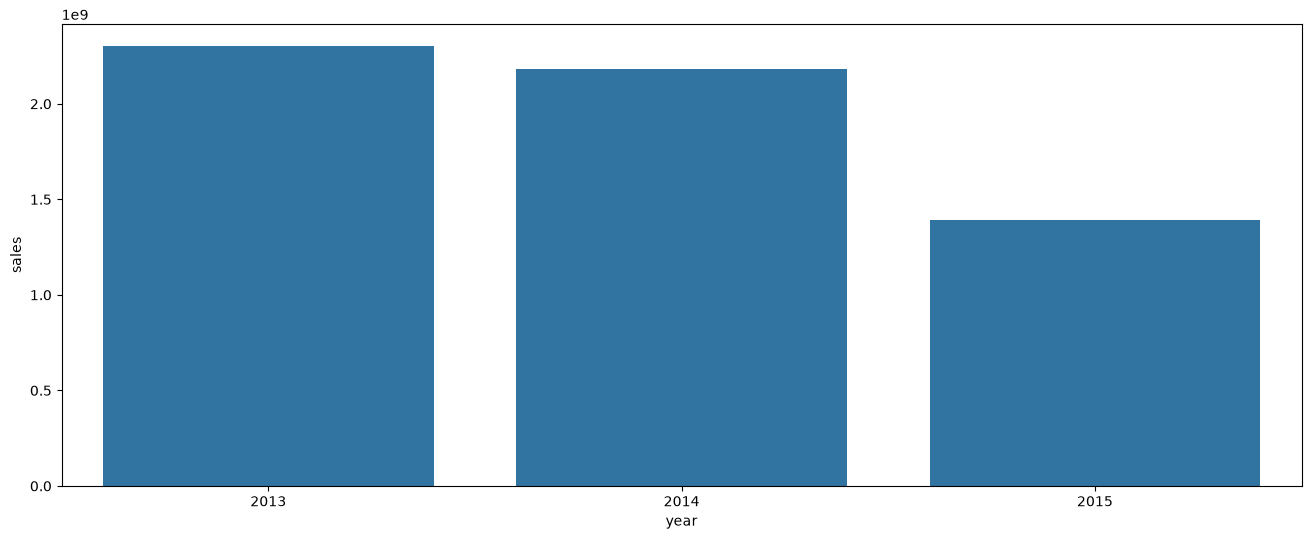

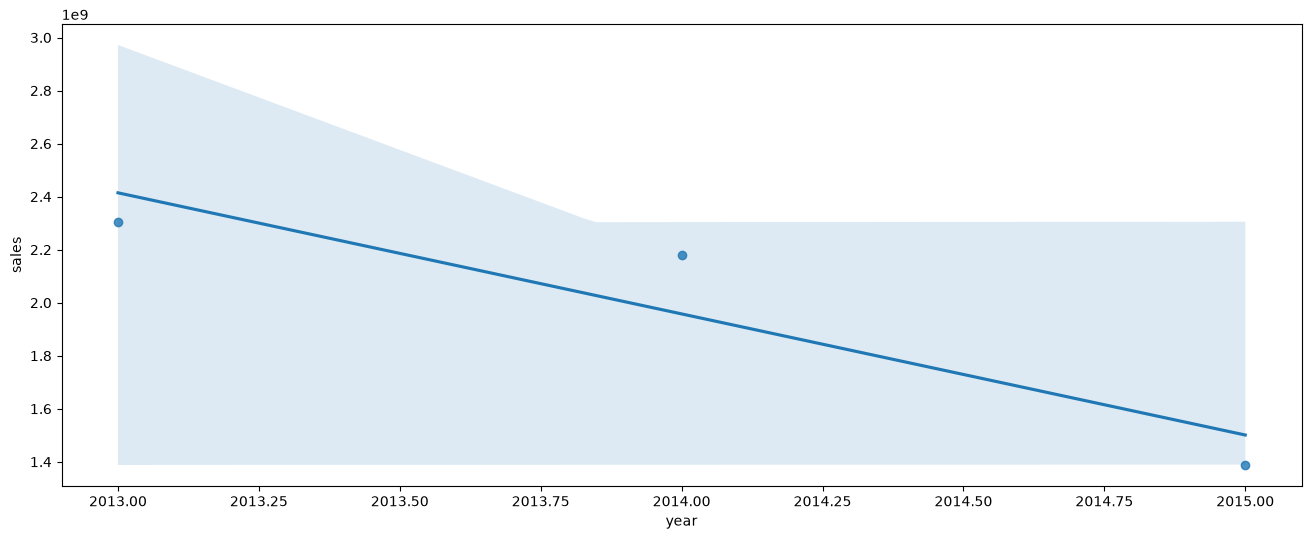

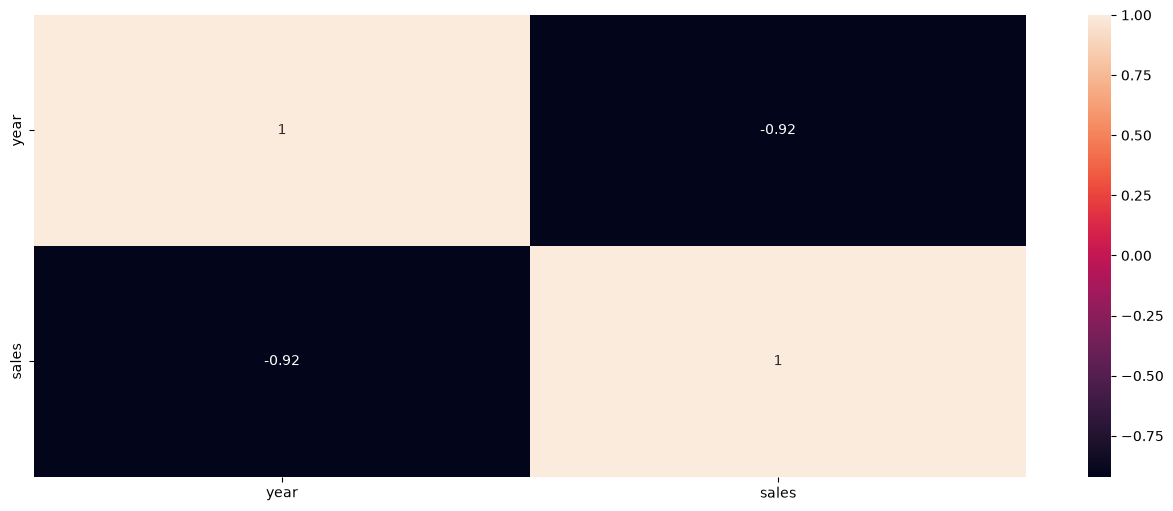

In [34]:
plt.figure(figsize=(16,6))
aux1 = df4[['year', 'sales']].groupby('year').sum().reset_index()
sns.barplot(x='year', y='sales', data=aux1);
plt.show()

plt.figure(figsize=(16,6))
sns.regplot(x='year', y='sales', data=aux1);
plt.show()

plt.figure(figsize=(16,6))
sns.heatmap(aux1.corr(method='pearson'), annot=True)
plt.show()


#### **H9.** Lojas deveriam vender mais no segundo semestre do ano

**False** - Lojas vendem MENOS no segundo semstre do ano

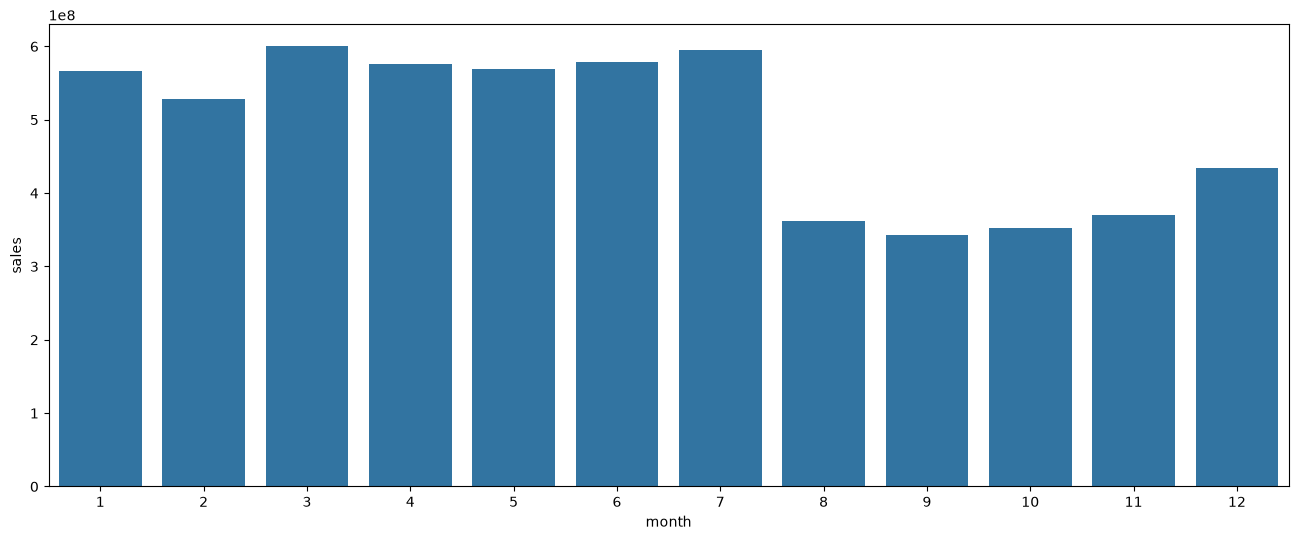

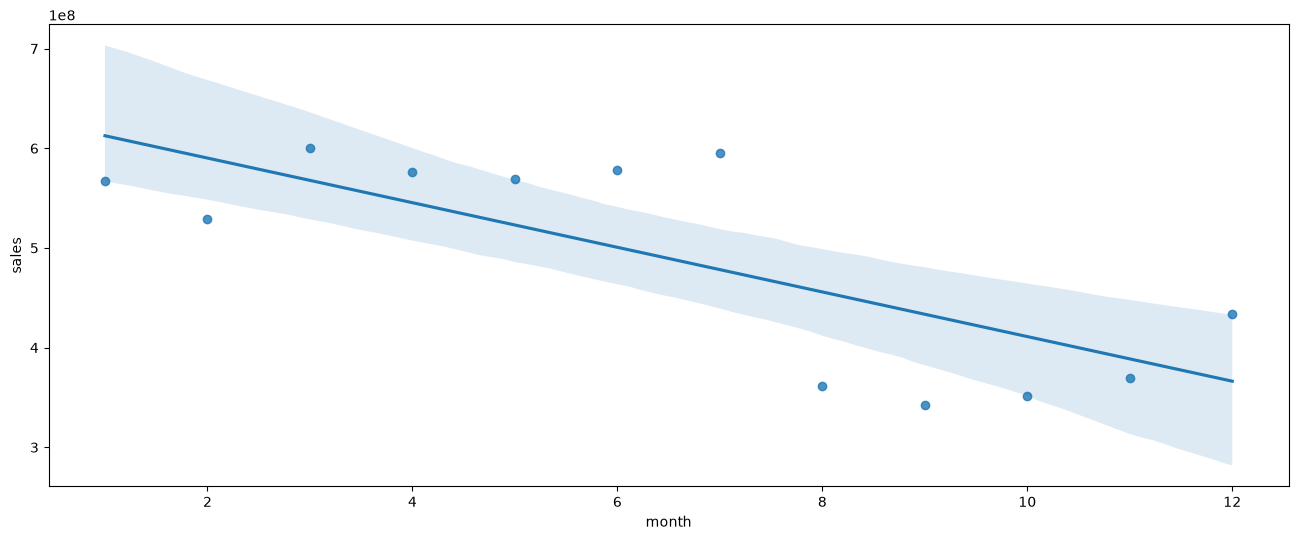

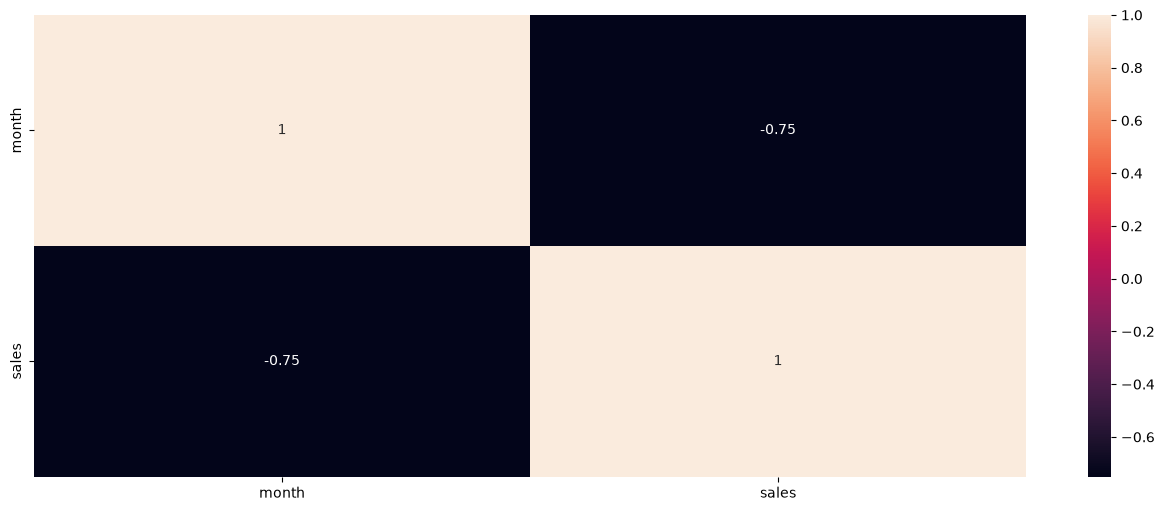

In [35]:
aux1 = df4[['month', 'sales']].groupby('month').sum().reset_index()

plt.figure(figsize=(16,6))
sns.barplot(x = 'month', y='sales', data=aux1)
plt.show()

plt.figure(figsize=(16,6))
sns.regplot(x = 'month', y='sales', data=aux1)
plt.show()

plt.figure(figsize=(16,6))
sns.heatmap(aux1.corr(method='pearson'), annot=True)
plt.show()

#### **H10.** Lojas deveriam vender mais depois do dia 10 de cada mês

**True** - As lojas vendem MAIS depois do dia 10 de cada mês

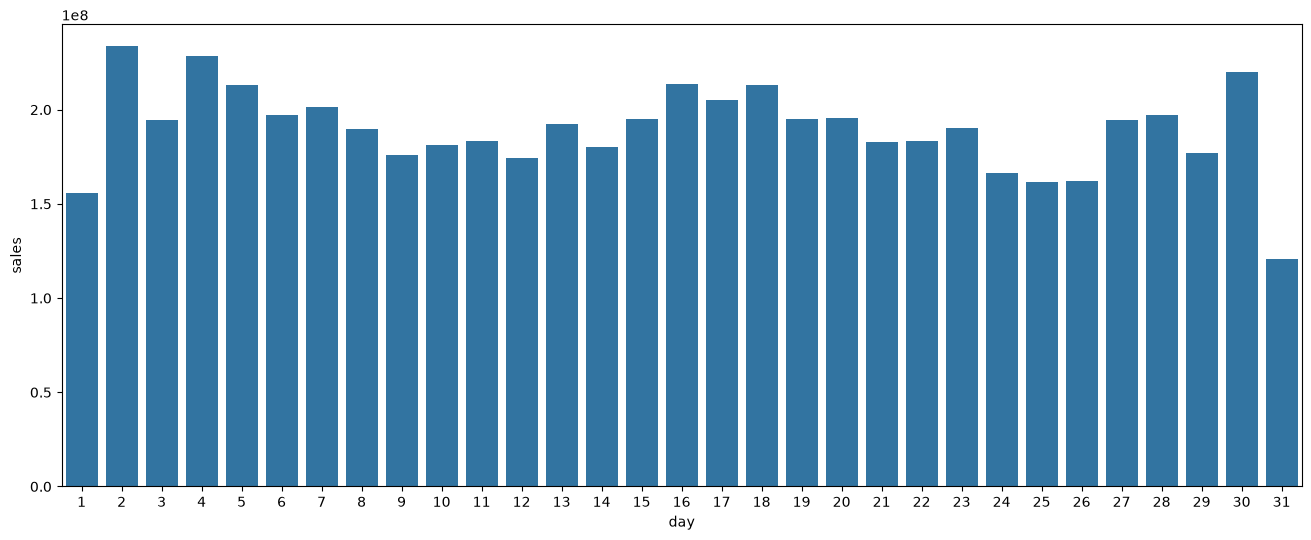

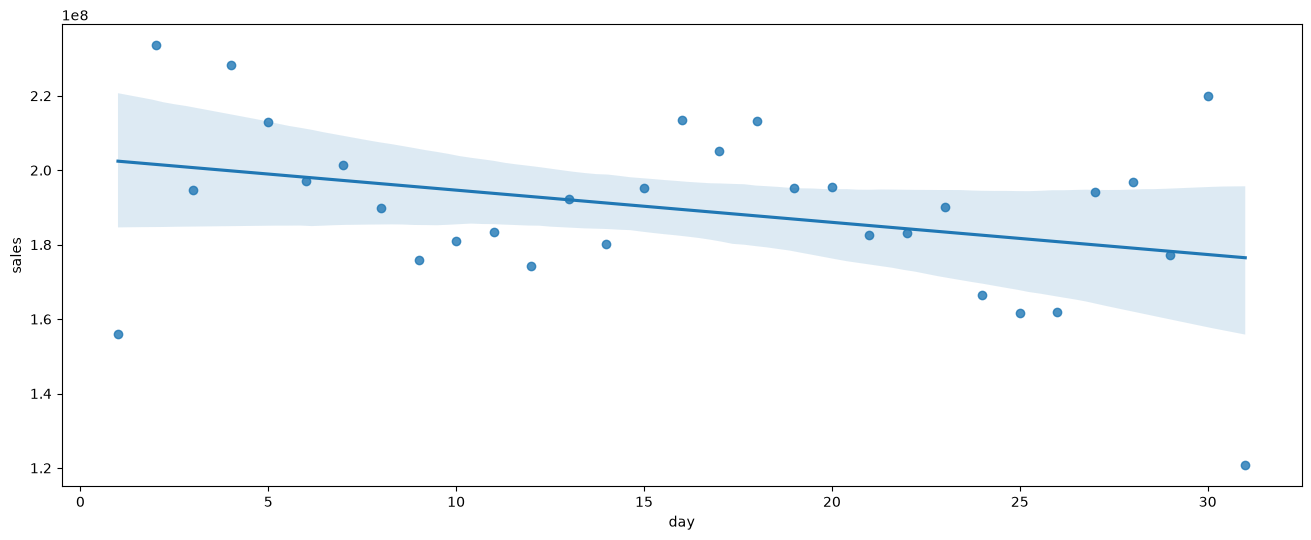

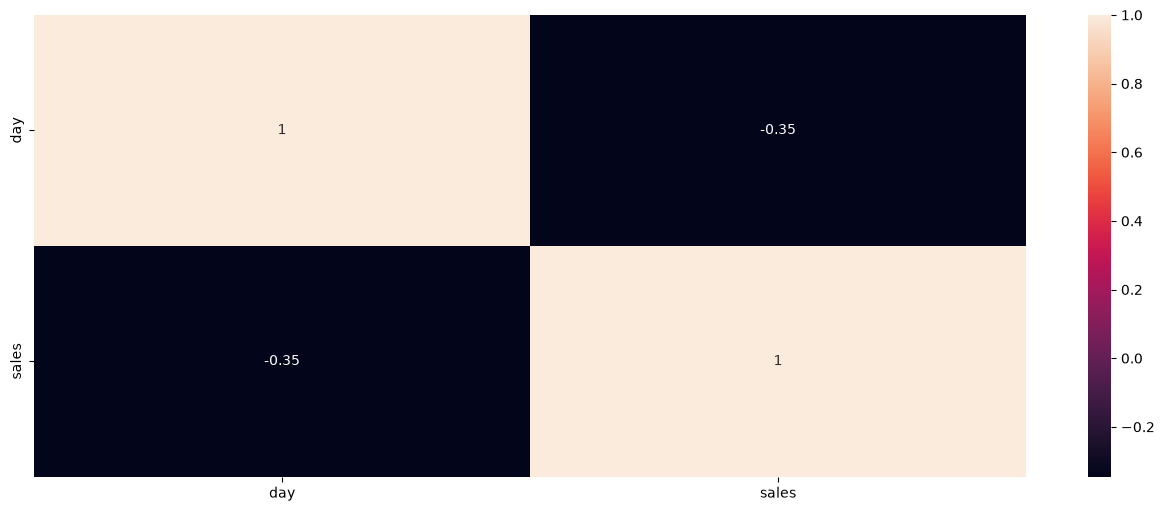

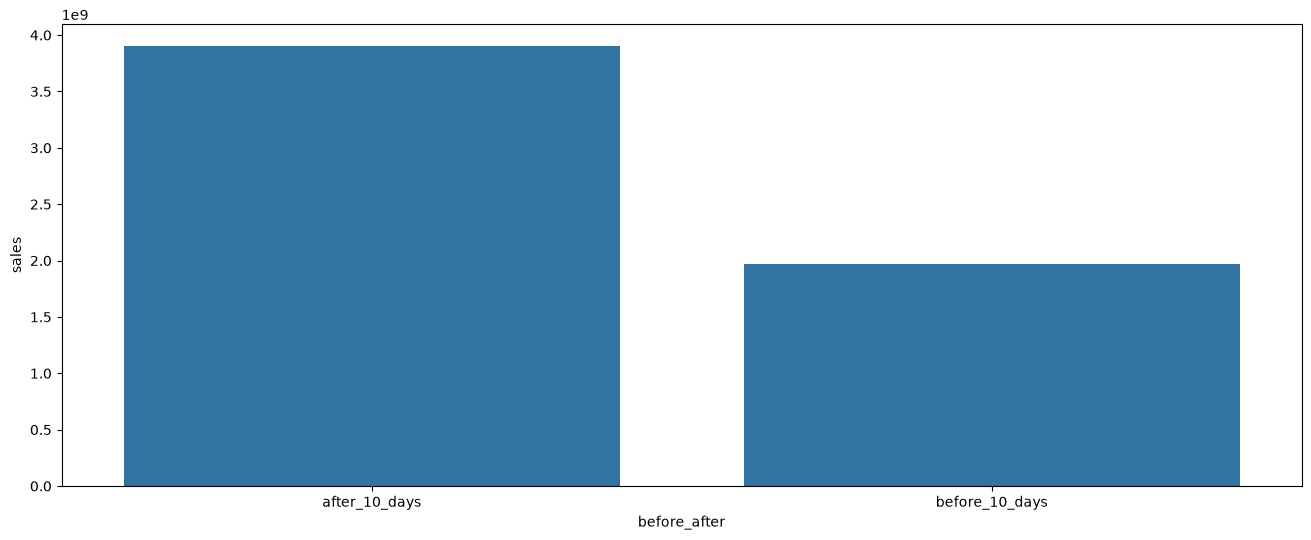

In [36]:
aux1 = df4[['day', 'sales']].groupby('day').sum().reset_index()

plt.figure(figsize=(16,6))
sns.barplot(x = 'day', y='sales', data=aux1)
plt.show()

plt.figure(figsize=(16,6))
sns.regplot(x = 'day', y='sales', data=aux1)
plt.show()

plt.figure(figsize=(16,6))
sns.heatmap(aux1.corr(method='pearson'), annot=True)
plt.show()

aux1['before_after'] = aux1['day'].apply(lambda x: 'before_10_days' if x <= 10 else 'after_10_days')

plt.figure(figsize=(16,6))
aux2 = aux1[['before_after','sales']].groupby('before_after').sum().reset_index()
sns.barplot(x = 'before_after', y='sales', data=aux2)
plt.show()


#### **H11.** Lojas deveriam vender menos aos finais de semana

**True** - As lojas vendem MENOS aos finais de semana

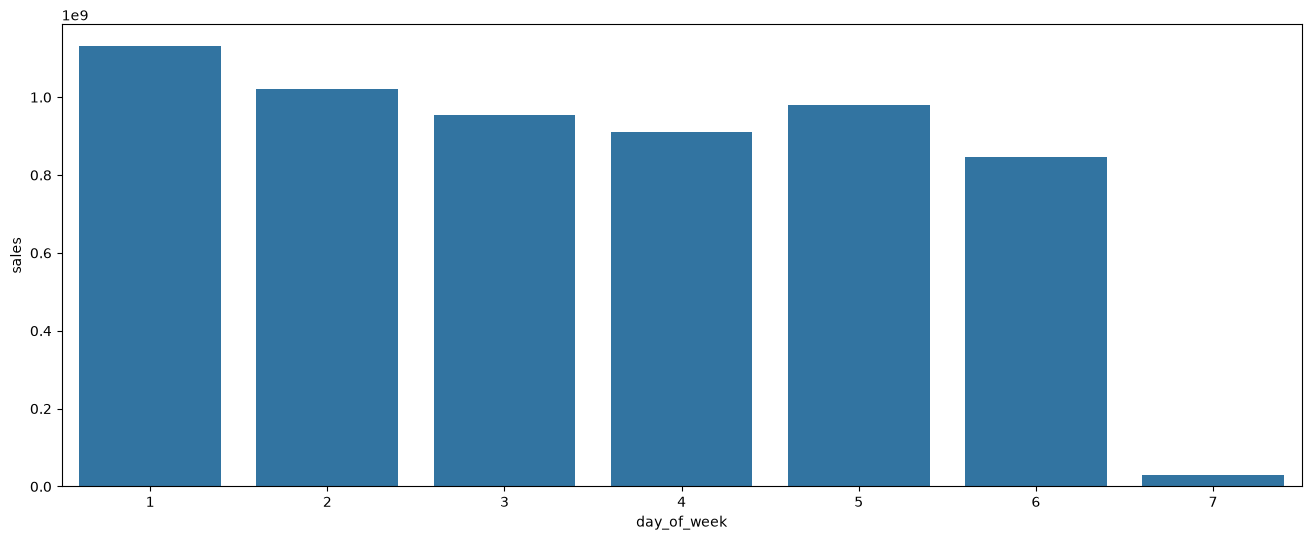

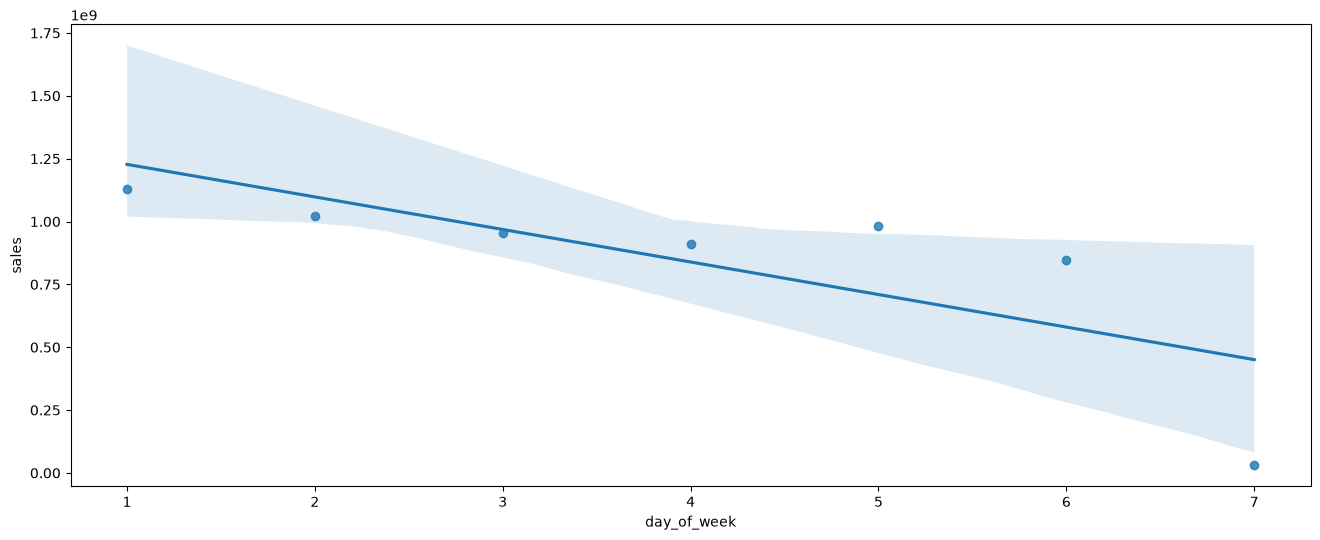

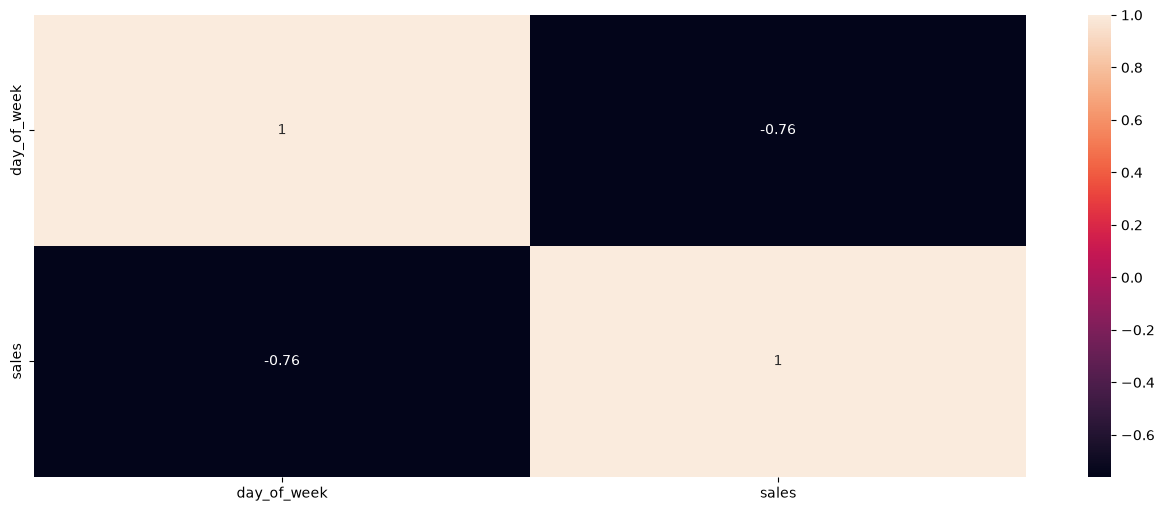

In [37]:
plt.figure(figsize=(16,6))
aux1 = df4[['day_of_week', 'sales']].groupby('day_of_week').sum().reset_index()
sns.barplot(x='day_of_week', y='sales', data=aux1);
plt.show()

plt.figure(figsize=(16,6))
sns.regplot(x='day_of_week', y='sales', data=aux1);
plt.show()

plt.figure(figsize=(16,6))
sns.heatmap(aux1.corr(method='pearson'), annot=True)
plt.show()

#### **H12.** Lojas deveriam vender menos durante os feriados escolares

**True** - As lojas vendem MENOS durante feriados escolares (exceto mês 8)

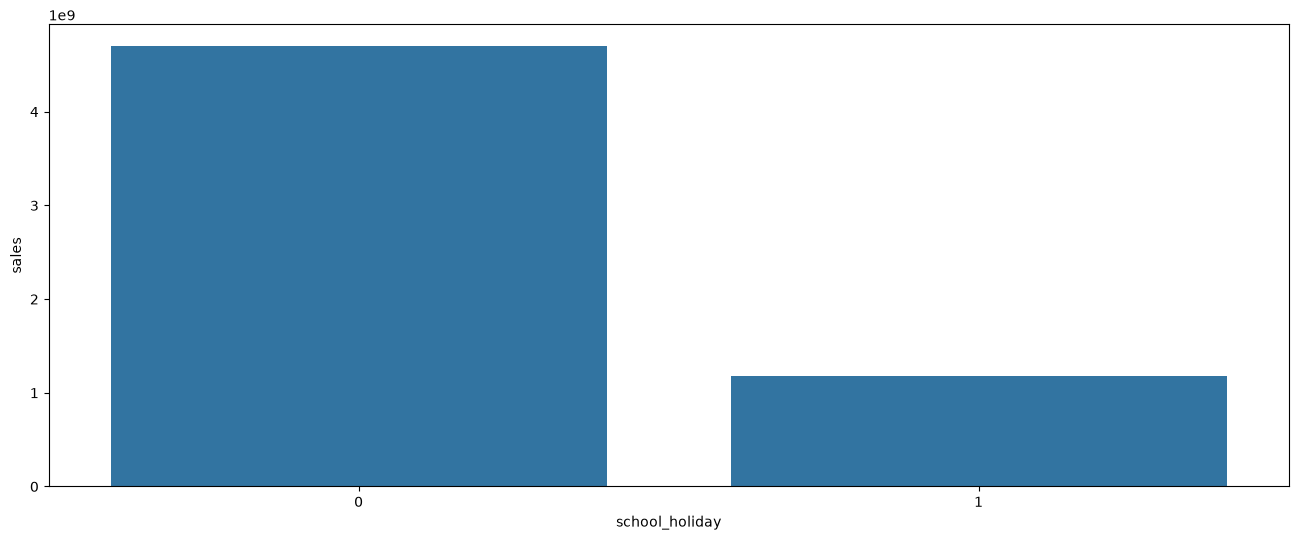

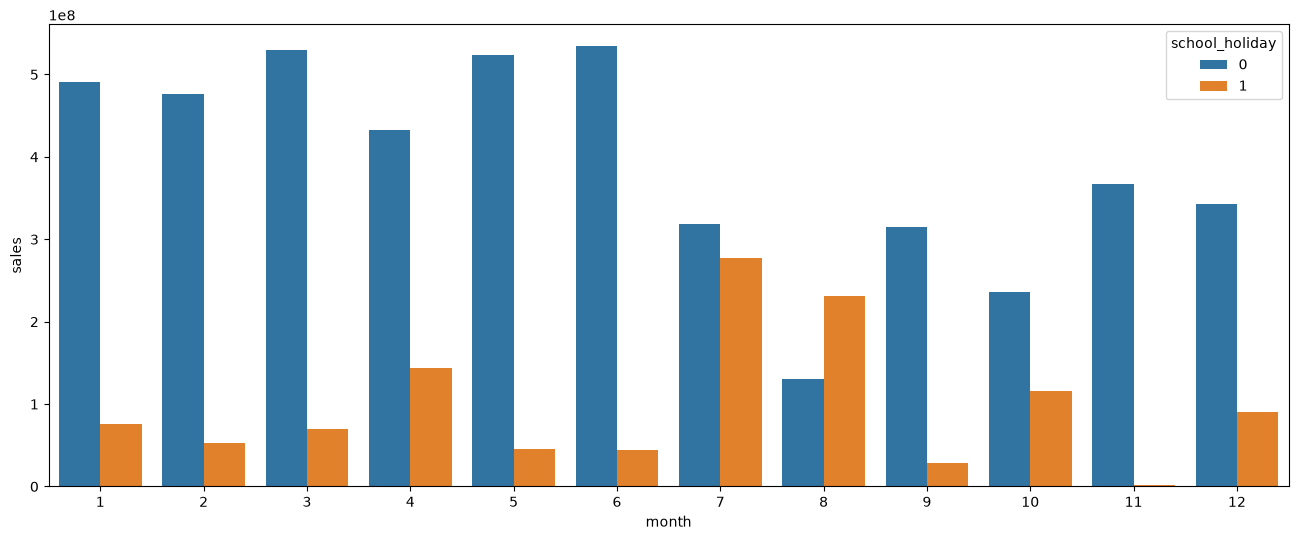

In [38]:
plt.figure(figsize=(16,6))
aux1 = df4[['school_holiday','sales']].groupby('school_holiday').sum().reset_index()
sns.barplot(x='school_holiday', y='sales', data=aux1);
plt.show()

plt.figure(figsize=(16,6))
aux2 = df4[['month', 'school_holiday','sales']].groupby(['month', 'school_holiday']).sum().reset_index()
sns.barplot(x='month', y='sales', hue='school_holiday', data=aux2);
plt.show()

In [39]:
tab = [['Hipoteses', 'Conclusão', 'Relevancia'],
       ['H1', 'Falsa', 'Baixa'],
       ['H2', 'Falsa', 'Média'],
       ['H3', 'Falsa', 'Média'],
       ['H4', 'Falsa', 'Baixa'],
       ['H5', '-', '-'],
       ['H6', 'Falsa', 'Baixa'],
       ['H7', 'Falsa', 'Média'],
       ['H8', 'Falsa', 'Alta'],
       ['H9', 'Falsa', 'Alta'],
       ['H10', 'Verdadeira', 'Alta'],
       ['H11', 'Verdadeira', 'Alta'],
       ['H12', 'Verdadeira', 'Baixa'],
    ]
print(tabulate(tab,headers='firstrow'))

Hipoteses    Conclusão    Relevancia
-----------  -----------  ------------
H1           Falsa        Baixa
H2           Falsa        Média
H3           Falsa        Média
H4           Falsa        Baixa
H5           -            -
H6           Falsa        Baixa
H7           Falsa        Média
H8           Falsa        Alta
H9           Falsa        Alta
H10          Verdadeira   Alta
H11          Verdadeira   Alta
H12          Verdadeira   Baixa


### 4.3 - Analise Multivariada

#### 4.3.1 - Numerical Attributs

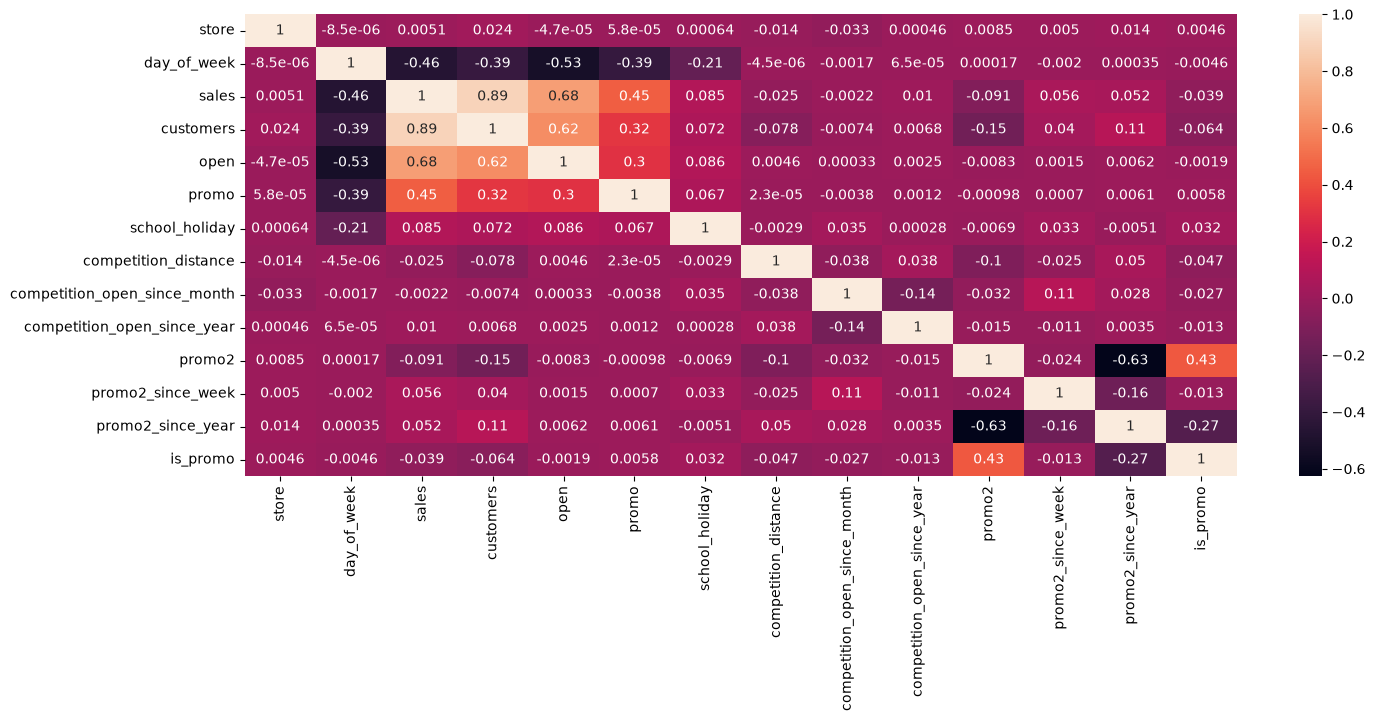

In [40]:
plt.figure(figsize=(16,6))
correlation = num_attributes.corr(method='pearson')
sns.heatmap(correlation, annot=True);
plt.show()

#### 4.3.2 - Categorical Attributs

In [41]:
a = df4.select_dtypes(include='str')
print(a)

          state_holiday store_type assortment year_week
0           regular_day          c      basic   2015-30
1           regular_day          a      basic   2015-30
2           regular_day          a      basic   2015-30
3           regular_day          c   extended   2015-30
4           regular_day          a      basic   2015-30
...                 ...        ...        ...       ...
1016776  public_holiday          b      basic   2013-00
1016827  public_holiday          b      extra   2013-00
1016863  public_holiday          b      extra   2013-00
1017042  public_holiday          b      extra   2013-00
1017190  public_holiday          b      extra   2013-00

[844338 rows x 4 columns]


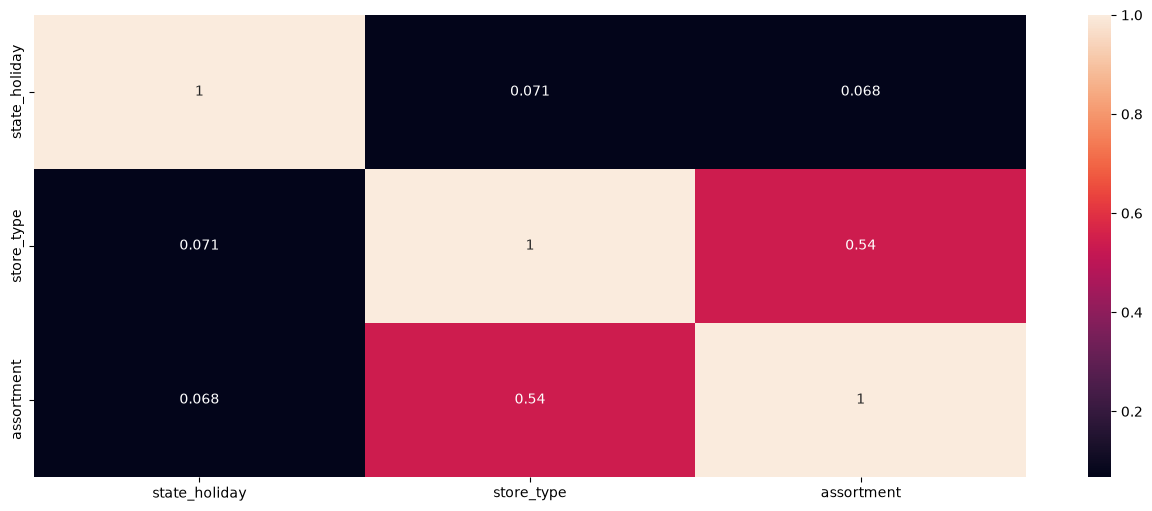

In [42]:
#Calculate creamer V
a1 = cramer_v(a['state_holiday'], a['state_holiday'])
a2 = cramer_v(a['state_holiday'], a['store_type'])
a3 = cramer_v(a['state_holiday'], a['assortment'])

a4 = cramer_v(a['store_type'], a['state_holiday'])
a5 = cramer_v(a['store_type'], a['store_type'])
a6 = cramer_v(a['store_type'], a['assortment'])

a7 = cramer_v(a['assortment'], a['state_holiday'])
a8 = cramer_v(a['assortment'], a['store_type'])
a9 = cramer_v(a['assortment'], a['assortment'])


#Final Dataset
d = pd.DataFrame({'state_holiday': [a1, a2, a3],
              'store_type': [a4, a5, a6],
              'assortment': [a7, a8, a9],
              })

d = d.set_index(d.columns)

plt.figure(figsize=(16,6))
sns.heatmap(d, annot=True)
plt.show()

# 5.0 - Data Preparation

In [95]:
df5 = df4.copy()

In [96]:
#Para separação entre treino e teste (que será a venda das 6 semanas subequentes do dataframe que temos)
df_lim = df5['date'].max() - datetime.timedelta(days=6*7)
df_lim

Timestamp('2015-06-19 00:00:00')

In [97]:
# traning dataset
X_train = df5[df5['date'] < df_lim].copy()
y_train = X_train['sales']

# test dataset
X_test = df5[df5['date'] >= df_lim].copy()
y_test = X_test['sales']

print('Training Min Date: {}'.format(X_train['date'].min()))
print('Training Max Date: {}'.format(X_train['date'].max()))

print('\nTest Min Date: {}'.format(X_test['date'].min()))
print('Test Max Date: {}'.format(X_test['date'].max()))

Training Min Date: 2013-01-01 00:00:00
Training Max Date: 2015-06-18 00:00:00

Test Min Date: 2015-06-19 00:00:00
Test Max Date: 2015-07-31 00:00:00


## 5.1 - Normalização

## 5.2 - Rescaling

In [98]:
rs_distance = RobustScaler()
rs_time     = RobustScaler()
mms_promo   = MinMaxScaler()
mms_year    = MinMaxScaler()

# competition_distance
X_train['competition_distance'] = rs_distance.fit_transform(X_train[['competition_distance']].values)
X_test['competition_distance']  = rs_distance.transform(X_test[['competition_distance']].values)

# competition_time_month
X_train['competition_time_month'] = rs_time.fit_transform(X_train[['competition_time_month']].values)
X_test['competition_time_month']  = rs_time.transform(X_test[['competition_time_month']].values)

# promo_time_week
X_train['promo_time_week'] = mms_promo.fit_transform(X_train[['promo_time_week']].values)
X_test['promo_time_week']  = mms_promo.transform(X_test[['promo_time_week']].values)

# year
X_train['year'] = mms_year.fit_transform(X_train[['year']].values)
X_test['year']  = mms_year.transform(X_test[['year']].values)

In [99]:
models_path_parameters = main_path / 'models' / 'parameters'
models_path_parameters.mkdir(exist_ok=True)

pickle.dump(rs_distance, open(models_path_parameters / 'rs_distance.pkl', 'wb'))
pickle.dump(rs_time,     open(models_path_parameters / 'rs_time.pkl',     'wb'))
pickle.dump(mms_promo,   open(models_path_parameters / 'mms_promo.pkl',   'wb'))
pickle.dump(mms_year,    open(models_path_parameters / 'mms_year.pkl',    'wb'))

## 5.3 - Transformação

### 5.3.1 - Encoding

In [ ]:
# state_holiday — One Hot Encoding
X_train = pd.get_dummies(X_train, prefix=['state_holiday'], columns=['state_holiday'], dtype=int)
X_test  = pd.get_dummies(X_test,  prefix=['state_holiday'], columns=['state_holiday'], dtype=int)

# Garante que X_test tenha exatamente as mesmas colunas que X_train
# (categorias ausentes no test recebem 0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# store_type — Label Encoding
le = LabelEncoder()
X_train['store_type'] = le.fit_transform(X_train['store_type'])
X_test['store_type']  = le.transform(X_test['store_type'])
pickle.dump(le, open(models_path_parameters / 'store_type.pkl', 'wb'))

# assortment — Ordinal Encoding
assortment_dict = {'basic': 1, 'extra': 2, 'extended': 3}
X_train['assortment'] = X_train['assortment'].map(assortment_dict)
X_test['assortment']  = X_test['assortment'].map(assortment_dict)

### 5.3.2 - Response Variable Transformation

In [101]:
y_train = np.log1p(y_train)
y_test  = np.log1p(y_test)

### 5.3.3 - Nature Transformation

In [102]:
for dataset in [X_train, X_test]:
    # day_of_week
    dataset['day_of_week_sin'] = dataset['day_of_week'].apply(lambda x: np.sin(x * (2. * np.pi / 7)))
    dataset['day_of_week_cos'] = dataset['day_of_week'].apply(lambda x: np.cos(x * (2. * np.pi / 7)))

    # month
    dataset['month_sin'] = dataset['month'].apply(lambda x: np.sin(x * (2. * np.pi / 12)))
    dataset['month_cos'] = dataset['month'].apply(lambda x: np.cos(x * (2. * np.pi / 12)))

    # day
    dataset['day_sin'] = dataset['day'].apply(lambda x: np.sin(x * (2. * np.pi / 30)))
    dataset['day_cos'] = dataset['day'].apply(lambda x: np.cos(x * (2. * np.pi / 30)))

    # week_of_year
    dataset['week_of_year_sin'] = dataset['week_of_year'].apply(lambda x: np.sin(x * (2. * np.pi / 52)))
    dataset['week_of_year_cos'] = dataset['week_of_year'].apply(lambda x: np.cos(x * (2. * np.pi / 52)))

In [103]:
X_train.head()

,store,day_of_week,date,sales,promo,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week,state_holiday_christmas,state_holiday_easter_holiday,state_holiday_public_holiday,state_holiday_regular_day,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_sin,day_cos,week_of_year_sin,week_of_year_cos
47945,1,4,2015-06-18,4645,1,0,2,1,-0.170968,9,2008,0,25,2015,0,1.0,6,18,25,2015-24,2008-09-01,0.904110,2015-06-15,0.290993,0,0,0,1,-0.433884,-0.900969,1.224647e-16,-1.0,-0.587785,-0.809017,0.120537,-0.992709
47946,2,4,2015-06-18,5154,1,0,0,1,-0.283871,11,2007,1,13,2010,0,1.0,6,18,25,2015-24,2007-11-01,1.041096,2010-03-22,0.921478,0,0,0,1,-0.433884,-0.900969,1.224647e-16,-1.0,-0.587785,-0.809017,0.120537,-0.992709
47947,3,4,2015-06-18,7537,1,0,0,1,1.903226,12,2006,1,14,2011,0,1.0,6,18,25,2015-24,2006-12-01,1.205479,2011-03-28,0.799076,0,0,0,1,-0.433884,-0.900969,1.224647e-16,-1.0,-0.587785,-0.809017,0.120537,-0.992709
47948,4,4,2015-06-18,8880,1,0,2,3,-0.275806,9,2009,0,25,2015,0,1.0,6,18,25,2015-24,2009-09-01,0.739726,2015-06-15,0.290993,0,0,0,1,-0.433884,-0.900969,1.224647e-16,-1.0,-0.587785,-0.809017,0.120537,-0.992709
47949,5,4,2015-06-18,4924,1,0,0,1,4.448387,4,2015,0,25,2015,0,1.0,6,18,25,2015-24,2015-04-01,-0.191781,2015-06-15,0.290993,0,0,0,1,-0.433884,-0.900969,1.224647e-16,-1.0,-0.587785,-0.809017,0.120537,-0.992709


# 6.0 - Feature Selection

In [52]:
X_train6 = X_train.copy()
X_test6  = X_test.copy()

## 6.1 - Column Filtering

In [53]:
cols_drop = ['week_of_year', 'day', 'month', 'day_of_week', 'promo_since', 'competition_since', 'year_week']

X_train6 = X_train6.drop(cols_drop, axis=1)
X_test6  = X_test6.drop(cols_drop, axis=1)

## 6.2 - Boruta as Feature Selector

In [54]:
#define train and test dataset for Boruta
#X_train_n = X_train6.drop(['date', 'sales'], axis = 1).values
#y_train_n = y_train.values.ravel()

#define RandomForest Regression
#rf = RandomForestRegressor (n_jobs=-1)

#boruta = BorutaPy(rf, n_estimators='auto', verbose=2, random_state=42).fit(X_train_n, y_train_n)

### 6.2.1 - Best Features from Boruta

In [55]:
# Boruta foi executado anteriormente (célula acima comentada).
# As features selecionadas estão fixadas manualmente na próxima célula.
# Descomente o bloco abaixo apenas se reexecutar o Boruta:
#
# cols_selected = boruta.support_.tolist()
# X_train_fs = X_train6.drop(['date', 'sales'], axis=1)
# cols_selected_boruta     = X_train_fs.iloc[:, cols_selected].columns.to_list()
# cols_not_selected_boruta = list(np.setdiff1d(X_train_fs.columns, cols_selected_boruta))
# print(cols_selected_boruta)

## 6.3 - Manual Feature Selection

In [56]:
cols_selected_boruta = ['store', 
                        'promo', 
                        'store_type', 
                        'assortment', 
                        'competition_distance', 
                        'competition_open_since_month', 
                        'competition_open_since_year', 
                        'promo2', 
                        'promo2_since_week', 
                        'promo2_since_year', 
                        'competition_time_month', 
                        'promo_time_week', 
                        'day_of_week_sin', 
                        'day_of_week_cos', 
                        'month_sin',
                        'month_cos', 
                        'day_sin', 
                        'day_cos',
                        'week_of_year_sin',
                        'week_of_year_cos']

#columns to add
feat_to_add = ['date', 'sales']

#final features
cols_selected_boruta_full = cols_selected_boruta.copy()
cols_selected_boruta_full.extend(feat_to_add)

# 7.0 - Machine Learning Modelling

In [57]:
X_train7 = X_train6.copy()
X_test7  = X_test6.copy()

In [58]:
# Colunas numéricas que o cross_validation deve re-escalar internamente
cv_robust_cols = ['competition_distance', 'competition_time_month']
cv_minmax_cols = ['promo_time_week']

# Snapshot de X_train com os valores originais (não-escalados) dessas colunas,
# para que o scaler seja fittado apenas no fold de treino dentro do CV.
X_train_cv = X_train.copy()
X_train_cv['competition_distance']   = rs_distance.inverse_transform(X_train[['competition_distance']].values)
X_train_cv['competition_time_month'] = rs_time.inverse_transform(X_train[['competition_time_month']].values)
X_train_cv['promo_time_week']        = mms_promo.inverse_transform(X_train[['promo_time_week']].values)

In [59]:
x_train = X_train7[cols_selected_boruta]
x_test  = X_test7[cols_selected_boruta]

# x_training usa snapshot não-escalado para que cross_validation re-fite os scalers por fold
x_training = X_train_cv[cols_selected_boruta_full]

## 7.1 - Average Model

In [60]:
aux1 = x_test.copy()
aux1['sales'] = y_test.copy()

#prediction
aux2 = aux1[['store', 'sales']].groupby('store').mean().reset_index().rename(columns={'sales':'predictions'})
aux1 = pd.merge(aux1, aux2, how='left', on='store')
yhat_baseline = aux1['predictions']

#performance
baseline_result = ml_error('Average Model', np.expm1 (y_test), np.expm1(yhat_baseline))
baseline_result

,Model Name,MAE,MAPE,RMSE
0,Average Model,1354.800353,0.455051,1835.135542


## 7.2 - Linear Regression Model

In [61]:
#model
lr = LinearRegression().fit(x_train, y_train)

#prediction
yhat_lr = lr.predict(x_test)

#performance
lr_result = ml_error('Linear Regression', np.expm1 (y_test), np.expm1(yhat_lr))
lr_result

,Model Name,MAE,MAPE,RMSE
0,Linear Regression,1867.089774,0.292694,2671.049215


### 7.2.1 - Linear Regression Model - Cross Validation

In [62]:
lr_result_cv = cross_validation(x_training, 5, 'Linear Regression', lr, verbose=False,
                               robust_cols=cv_robust_cols, minmax_cols=cv_minmax_cols)
lr_result_cv

,Model Name,MAE CV MEAN,MAPE CV MEAN,RMSE CV MEAN
0,Linear Regression,2081.73 +/- 295.63,0.3 +/- 0.02,2952.52 +/- 468.37


## 7.3 - Linear Regression Regularized Model - Lasso

In [63]:
#model
lrr = Lasso( alpha=0.01 ).fit(x_train, y_train)

#prediction
yhat_lrr = lrr.predict(x_test)

#performance
lrr_result = ml_error('Linear Regression Lasso', np.expm1 (y_test), np.expm1(yhat_lrr))
lrr_result

,Model Name,MAE,MAPE,RMSE
0,Linear Regression Lasso,1891.704881,0.289106,2744.451737


### 7.3.1 - Linear Regression Regularized Model - Lasso - Cross Validation

In [64]:
lrr_result_cv = cross_validation(x_training, 5, 'Linear Regression - Lasso', lrr, verbose=False,
                                robust_cols=cv_robust_cols, minmax_cols=cv_minmax_cols)
lrr_result_cv

,Model Name,MAE CV MEAN,MAPE CV MEAN,RMSE CV MEAN
0,Linear Regression - Lasso,2116.38 +/- 341.5,0.29 +/- 0.01,3057.75 +/- 504.26


## 7.4 - Random Forest

In [65]:
#model
rf = RandomForestRegressor(n_estimators = 100, n_jobs=-1, random_state=42).fit(x_train, y_train)

#prediction
yhat_rf = rf.predict(x_test)

#performance
rf_result = ml_error('Random Forest Regressor', np.expm1 (y_test), np.expm1(yhat_rf))
rf_result

,Model Name,MAE,MAPE,RMSE
0,Random Forest Regressor,679.203513,0.099857,1010.040263


### 7.4.1 - Random Forest - Cross Validation

In [66]:
rf_result_cv = cross_validation(x_training, 5, 'Random Forest Regressor', rf, verbose=True,
                               robust_cols=cv_robust_cols, minmax_cols=cv_minmax_cols)
rf_result_cv


KFold Number: 5

KFold Number: 4

KFold Number: 3

KFold Number: 2

KFold Number: 1


,Model Name,MAE CV MEAN,MAPE CV MEAN,RMSE CV MEAN
0,Random Forest Regressor,837.45 +/- 218.41,0.12 +/- 0.02,1255.62 +/- 318.34


## 7.5 - XGBoost Regressor

In [67]:
#model
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', 
                             n_estimators = 100, 
                             eta=0.3, 
                             max_depth=6, 
                             subsample=0.7,
                             colsample_bytree=0.9).fit(x_train, y_train)

#prediction
yhat_xgb = model_xgb.predict(x_test)

#performance
xgb_result = ml_error('XGBoost Regressor', np.expm1 (y_test), np.expm1(yhat_xgb))
xgb_result

,Model Name,MAE,MAPE,RMSE
0,XGBoost Regressor,875.034119,0.130055,1265.17736


### 7.5.1 - XGBoost Regressor - Cross Validation

In [68]:
xgb_result_cv = cross_validation(x_training, 5, 'XGBoost Regressor', model_xgb, verbose=True,
                                robust_cols=cv_robust_cols, minmax_cols=cv_minmax_cols)
xgb_result_cv


KFold Number: 5

KFold Number: 4

KFold Number: 3

KFold Number: 2

KFold Number: 1


,Model Name,MAE CV MEAN,MAPE CV MEAN,RMSE CV MEAN
0,XGBoost Regressor,1076.89 +/- 157.79,0.15 +/- 0.01,1544.02 +/- 216.12


## 7.6 - Compare Model's Performance

### 7.6.1 - Single Performance

In [69]:
modelling_results=pd.concat([baseline_result, lr_result, lrr_result, rf_result, xgb_result])
modelling_results.sort_values('RMSE')

,Model Name,MAE,MAPE,RMSE
0,Random Forest Regressor,679.203513,0.099857,1010.040263
0,XGBoost Regressor,875.034119,0.130055,1265.177360
0,Average Model,1354.800353,0.455051,1835.135542
0,Linear Regression,1867.089774,0.292694,2671.049215
0,Linear Regression Lasso,1891.704881,0.289106,2744.451737


### 7.6.2 - Real Performance Cross Validation

In [70]:
modelling_results_cv=pd.concat([lr_result_cv, lrr_result_cv, rf_result_cv, xgb_result_cv])
modelling_results_cv

,Model Name,MAE CV MEAN,MAPE CV MEAN,RMSE CV MEAN
0,Linear Regression,2081.73 +/- 295.63,0.3 +/- 0.02,2952.52 +/- 468.37
0,Linear Regression - Lasso,2116.38 +/- 341.5,0.29 +/- 0.01,3057.75 +/- 504.26
0,Random Forest Regressor,837.45 +/- 218.41,0.12 +/- 0.02,1255.62 +/- 318.34
0,XGBoost Regressor,1076.89 +/- 157.79,0.15 +/- 0.01,1544.02 +/- 216.12


# 8.0 - Hyperparameter Fine Tunning

## 8.1 - Random Search

In [71]:
param ={'n_estimators': [1500, 1700, 2500, 3000, 3500],
        'eta': [0.1, 0.3],
        'max_depth': [3, 5, 9],
        'subsample': [0.01, 0.03],
        'colsample_bytree': [0.1, 0.5, 0.7],
        'min_child_weight': [3, 8, 15]
}

MAX_EVAL = 5

In [72]:
final_result = pd.DataFrame()

for i in range(MAX_EVAL):
    #chose values for paramters randomly
    hp = {k: random.sample(v,1)[0] for k, v in param.items()}
    print(hp)
    #model
    model_xgb = xgb.XGBRegressor(objective='reg:squarederror', 
                                n_estimators = hp['n_estimators'], 
                                eta=hp['eta'], 
                                max_depth=hp['max_depth'], 
                                subsample=hp['subsample'],
                                colsample_bytree=hp['colsample_bytree'],
                                min_child_weight=hp['min_child_weight'])

    #performance
    result = cross_validation(x_training, 5, 'XGBoost Regressor', model_xgb, verbose=False,
                              robust_cols=cv_robust_cols, minmax_cols=cv_minmax_cols)
    final_result = pd.concat([final_result, result])

final_result

{'n_estimators': 3500, 'eta': 0.1, 'max_depth': 9, 'subsample': 0.01, 'colsample_bytree': 0.5, 'min_child_weight': 8}
{'n_estimators': 3000, 'eta': 0.3, 'max_depth': 5, 'subsample': 0.03, 'colsample_bytree': 0.5, 'min_child_weight': 15}
{'n_estimators': 3500, 'eta': 0.3, 'max_depth': 3, 'subsample': 0.01, 'colsample_bytree': 0.7, 'min_child_weight': 3}
{'n_estimators': 3000, 'eta': 0.3, 'max_depth': 9, 'subsample': 0.01, 'colsample_bytree': 0.7, 'min_child_weight': 15}
{'n_estimators': 1500, 'eta': 0.3, 'max_depth': 9, 'subsample': 0.01, 'colsample_bytree': 0.1, 'min_child_weight': 15}


,Model Name,MAE CV MEAN,MAPE CV MEAN,RMSE CV MEAN
0,XGBoost Regressor,1393.93 +/- 199.83,0.19 +/- 0.02,1934.42 +/- 292.26
0,XGBoost Regressor,1301.27 +/- 211.09,0.18 +/- 0.02,1809.0 +/- 314.63
0,XGBoost Regressor,1442.72 +/- 258.22,0.2 +/- 0.03,2054.31 +/- 436.49
0,XGBoost Regressor,26556727.81 +/- 19270922.61,4048.74 +/- 2958.86,2259834115.36 +/- 1650779031.6
0,XGBoost Regressor,1469.23 +/- 215.56,0.21 +/- 0.02,2022.14 +/- 328.38


## 8.2 - Final Model

In [73]:
param_tuned ={'n_estimators': 1500,
        'eta': 0.1,
        'max_depth': 9,
        'subsample': 0.03,
        'colsample_bytree': 0.7,
        'min_child_weight': 8
}

In [74]:
#model
model_xgb_tunned = xgb.XGBRegressor(objective='reg:squarederror', 
                                    n_estimators = param_tuned['n_estimators'], 
                                    eta=param_tuned['eta'], 
                                    max_depth=param_tuned['max_depth'], 
                                    subsample=param_tuned['subsample'],
                                    colsample_bytree=param_tuned['colsample_bytree'],
                                    min_child_weight=param_tuned['min_child_weight']).fit(x_train, y_train)

#prediction
yhat_xgb_tunned = model_xgb_tunned.predict(x_test)

#performance
xgb_result_tunned = ml_error ('XGBoost Regressor Tunned', np.expm1(y_test), np.expm1(yhat_xgb_tunned))
xgb_result_tunned

,Model Name,MAE,MAPE,RMSE
0,XGBoost Regressor Tunned,754.599204,0.110229,1081.996911


In [76]:
mpe = ((np.expm1(y_test) - np.expm1(yhat_xgb_tunned)) / np.expm1(y_test)).mean()
print(f'MPE: {mpe:.4f}  ({mpe*100:.2f}%)  — viés direcional do modelo')

MPE: 0.0003  (0.03%)  — viés direcional do modelo


In [77]:
sales_range = np.expm1(y_test).max() - np.expm1(y_test).min()
media_final = np.expm1(y_test).mean()

mae_final  = xgb_result_tunned['MAE'].values[0]
erro_final = round((mae_final / media_final) * 100, 2)

print(f'MAE: R$ {mae_final:,.2f}')
print(f'O erro médio da previsão é {erro_final} %')

MAE: R$ 754.60
O erro médio da previsão é 10.79 %


# 9.0 - Tradução e Interpretação do Erro

In [78]:
df9 = X_test[cols_selected_boruta_full].copy()

# X_test['sales'] está em escala original; y_test já está em log-scale
df9['sales']       = np.expm1(y_test)
df9['predictions'] = np.expm1(yhat_xgb_tunned)

## 9.1 - Bussines Performance

In [79]:
# sum of prediction
df91 = df9[['store', 'predictions']].groupby('store').sum().reset_index()

#MAE and MAPE
df9_aux1 = df9[['store','sales','predictions']].groupby('store').apply(lambda x: mean_absolute_error(x['sales'], x['predictions'])).reset_index().rename(columns={0: 'MAE'})
df9_aux2 = df9[['store','sales','predictions']].groupby('store').apply(lambda x: mean_absolute_percentage_error(x['sales'], x['predictions'])).reset_index().rename(columns={0: 'MAPE'})

#Merge
df9_aux3 = pd.merge(df9_aux1, df9_aux2, how='inner', on='store')
df92 = pd.merge(df91, df9_aux3, how='inner', on='store')

#Scenarios
df92['worst_secnario'] = df92['predictions'] - df92['MAE']
df92['best_secnario'] = df92['predictions'] + df92['MAE']

#order columns
df92 = df92[['store', 'predictions', 'worst_secnario', 'best_secnario', 'MAE', 'MAPE']]
df92

,store,predictions,worst_secnario,best_secnario,MAE,MAPE
0,1,158589.453125,158293.046552,158885.859698,296.406573,0.066862
1,2,170957.671875,170402.298459,171513.045291,555.373416,0.112332
2,3,258923.000000,258348.613215,259497.386785,574.386785,0.088073
3,4,328236.750000,327076.086518,329397.413482,1160.663482,0.109495
4,5,185985.000000,185335.752125,186634.247875,649.247875,0.164843
...,...,...,...,...,...,...
1110,1111,177762.687500,177004.159971,178521.215029,758.527529,0.162601
1111,1112,339417.125000,338490.741673,340343.508327,926.383327,0.110392
1112,1113,236640.500000,236018.067172,237262.932828,622.432828,0.093270
1113,1114,774540.875000,771722.568148,777359.181852,2818.306852,0.121065


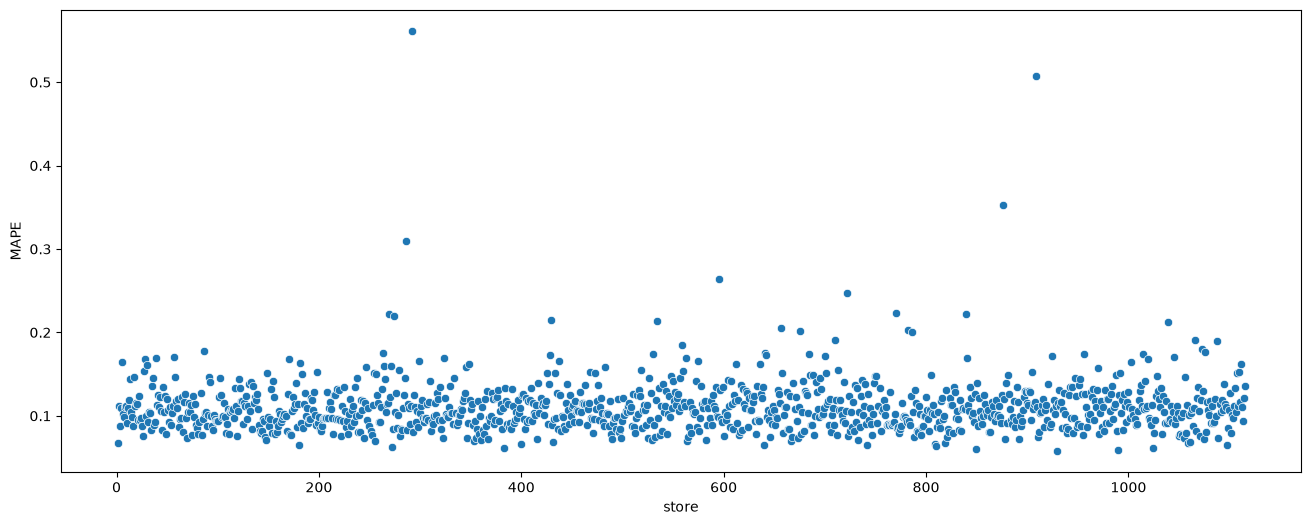

In [80]:
plt.figure(figsize=(16, 6))
sns.scatterplot(x='store', y='MAPE', data=df92)
plt.show()

## 9.2 - Total Performance

In [81]:
total_predictions = df92['predictions'].sum()
total_worst       = df92['worst_secnario'].sum()
total_best        = df92['best_secnario'].sum()

total_perf = pd.DataFrame({
    'Scenario':     ['Pessimista', 'Previsão', 'Otimista'],
    'Total Vendas': [total_worst,  total_predictions, total_best]
})
total_perf['Total Vendas'] = total_perf['Total Vendas'].apply(lambda x: f'R$ {x:,.2f}')
total_perf

,Scenario,Total Vendas
0,Pessimista,"R$ 283,505,926.53"
1,Previsão,"R$ 284,351,072.00"
2,Otimista,"R$ 285,196,184.16"


## 9.3 - Machine Learning Performance

In [82]:
df9['error'] = df9['sales'] - df9['predictions']
df9['error_rate'] = df9['predictions'] / df9['sales']

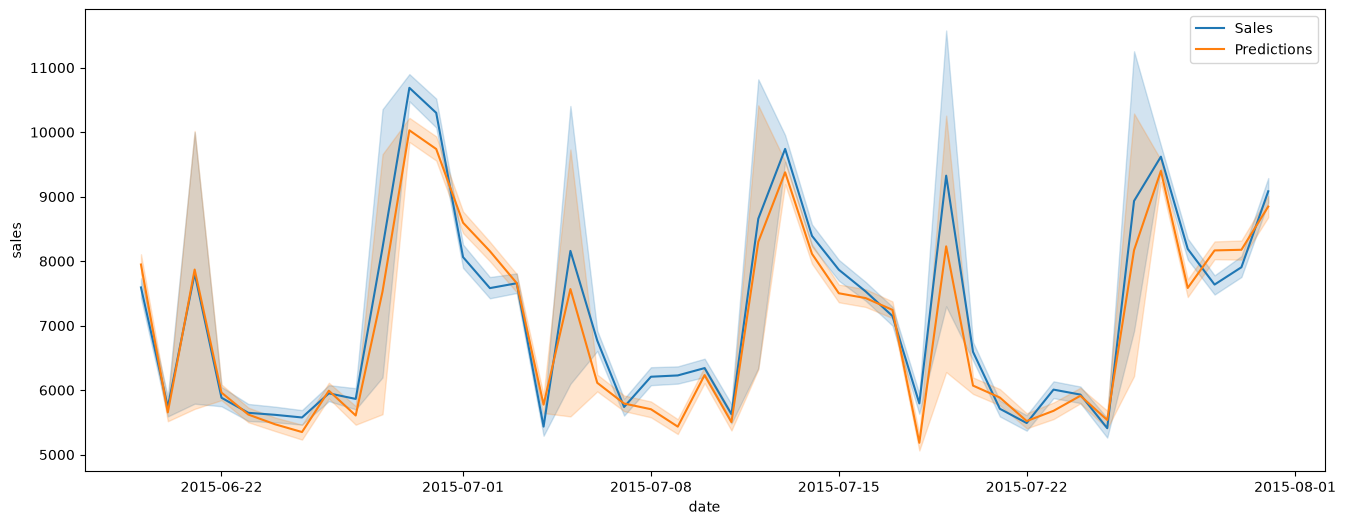

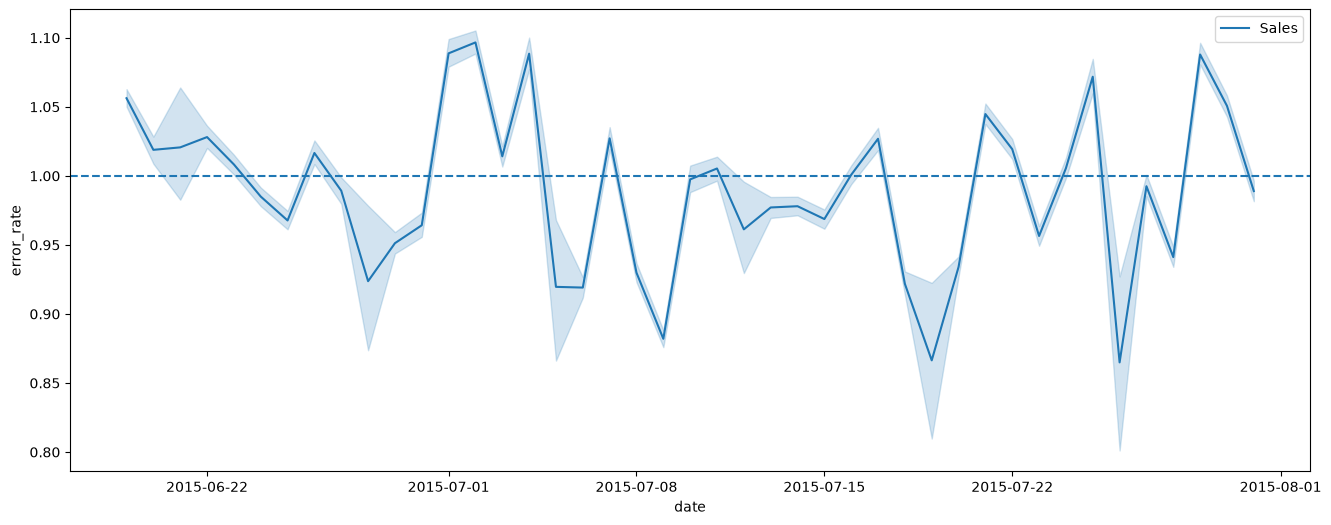

<Figure size 1600x600 with 0 Axes>

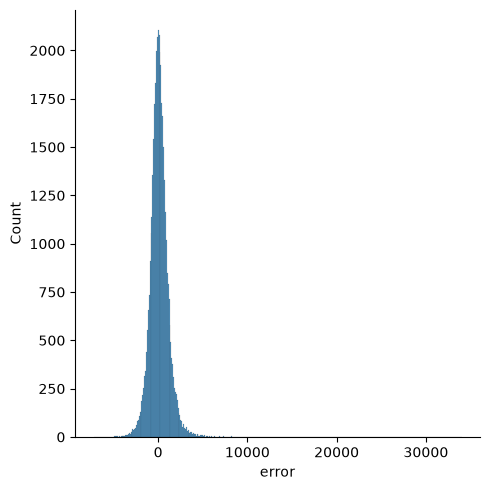

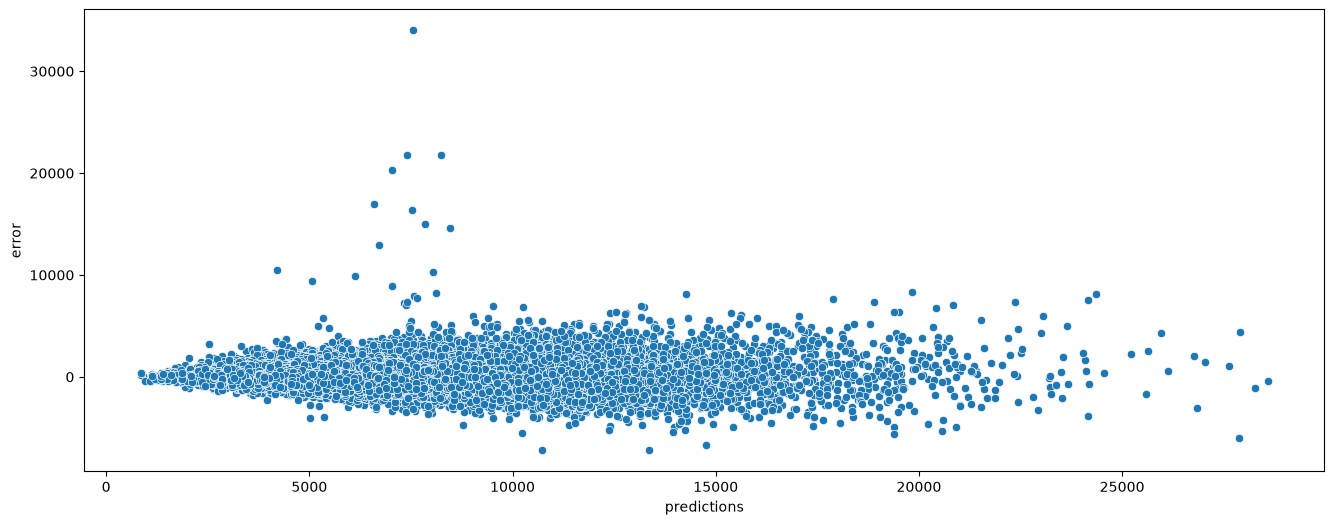

In [83]:
plt.figure(figsize=(16, 6))
sns.lineplot(x='date', y='sales', data=df9, label='Sales')
sns.lineplot(x='date', y='predictions', data=df9, label='Predictions')
plt.show()

plt.figure(figsize=(16, 6))
sns.lineplot(x='date', y='error_rate', data=df9, label='Sales')
plt.axhline(1, linestyle='--')
plt.show()

plt.figure(figsize=(16, 6))
sns.displot(df9['error'])
plt.show()

plt.figure(figsize=(16, 6))
sns.scatterplot(x=df9['predictions'], y=df9['error'])
plt.show()

# 10.0 - Deploy Model to Production

In [ ]:
models_path_ml = main_path / 'models' / 'ml_model'
models_path_ml.mkdir(exist_ok=True)

pickle.dump(model_xgb_tunned, open(models_path_ml / 'model_xgb_tunned.pkl', 'wb'))

## 10.1 - Rossmann Class

In [18]:
import pickle
import inflection
import pandas as pd
import numpy as np
import datetime
from pathlib import Path

if 'main_path' not in globals():
    main_path = Path.cwd().parent  # notebooks/ -> project root

# Define path
models_path_parameters = main_path / "models" / "parameters"
models_path_parameters.mkdir(exist_ok=True)

class Rossmann(object):
    def __init__(self):
        self.competition_distance_scaler = pickle.load(open(models_path_parameters / "rs_distance.pkl",  "rb"))
        self.competition_time_month      = pickle.load(open(models_path_parameters / "rs_time.pkl",      "rb"))
        self.promo_time_week             = pickle.load(open(models_path_parameters / "mms_promo.pkl",    "rb"))
        self.year                        = pickle.load(open(models_path_parameters / "mms_year.pkl",     "rb"))
        self.store_type                  = pickle.load(open(models_path_parameters / "store_type.pkl",   "rb"))

    def data_cleaning(self, df1):
        cols_old = ["Store", "DayOfWeek", "Date", "Open", "Promo", "StateHoliday", "SchoolHoliday",
                    "StoreType", "Assortment", "CompetitionDistance", "CompetitionOpenSinceMonth",
                    "CompetitionOpenSinceYear", "Promo2", "Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"]

        df1 = df1[cols_old].copy()

        snakecase = lambda x: inflection.underscore(x)
        cols_new = list(map(snakecase, cols_old))
        df1.columns = cols_new

        df1["date"] = pd.to_datetime(df1["date"])

        df1["competition_distance"] = df1["competition_distance"].apply(
            lambda x: 200000.0 if pd.isna(x) else x)

        df1["competition_open_since_month"] = df1.apply(
            lambda x: x["date"].month if pd.isna(x["competition_open_since_month"])
                      else x["competition_open_since_month"], axis=1)

        df1["competition_open_since_year"] = df1.apply(
            lambda x: x["date"].year if pd.isna(x["competition_open_since_year"])
                      else x["competition_open_since_year"], axis=1)

        df1["promo2_since_week"] = df1.apply(
            lambda x: int(x["date"].isocalendar().week) if pd.isna(x["promo2_since_week"])
                      else x["promo2_since_week"], axis=1)

        df1["promo2_since_year"] = df1.apply(
            lambda x: x["date"].year if pd.isna(x["promo2_since_year"])
                      else x["promo2_since_year"], axis=1)

        month_map = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
                     7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

        df1["promo_interval"] = df1["promo_interval"].fillna("0")
        df1["month_map"] = df1["date"].dt.month.map(month_map)
        df1["is_promo"] = df1[["promo_interval", "month_map"]].apply(
            lambda x: 0 if x["promo_interval"] == "0"
                      else 1 if x["month_map"] in x["promo_interval"].split(",")
                      else 0, axis=1)

        df1["competition_open_since_month"] = df1["competition_open_since_month"].astype(int)
        df1["competition_open_since_year"]  = df1["competition_open_since_year"].astype(int)
        df1["promo2_since_week"]            = df1["promo2_since_week"].astype(int)
        df1["promo2_since_year"]            = df1["promo2_since_year"].astype(int)

        return df1

    def feature_engineering(self, df2):
        df2["year"]         = df2["date"].dt.year
        df2["month"]        = df2["date"].dt.month
        df2["day"]          = df2["date"].dt.day
        df2["week_of_year"] = df2["date"].dt.isocalendar().week.astype(int)
        df2["year_week"]    = df2["date"].dt.strftime("%Y-%W")

        df2["competition_since"] = df2.apply(
            lambda x: datetime.datetime(year=x["competition_open_since_year"],
                                        month=x["competition_open_since_month"], day=1), axis=1)
        df2["competition_time_month"] = (df2["date"] - df2["competition_since"]).dt.days // 30

        df2["promo_since"] = df2["promo2_since_year"].astype(str) + "-" + df2["promo2_since_week"].astype(str)
        df2["promo_since"] = df2["promo_since"].apply(
            lambda x: datetime.datetime.strptime(x + "-1", "%Y-%W-%w") - datetime.timedelta(days=7))
        df2["promo_time_week"] = (df2["date"] - df2["promo_since"]).dt.days // 7

        df2["assortment"] = df2["assortment"].apply(
            lambda x: "basic" if x == "a" else "extra" if x == "b" else "extended")

        df2["state_holiday"] = df2["state_holiday"].apply(
            lambda x: "public_holiday" if x == "a" else "easter_holiday" if x == "b"
                      else "christmas" if x == "c" else "regular_day")

        df2 = df2[df2["open"] != 0]

        cols_drop = ["open", "promo_interval", "month_map"]
        df2 = df2.drop(cols_drop, axis=1)

        return df2

    def data_preparation(self, df5):
        X_test = df5.copy()

        X_test["competition_distance"]   = self.competition_distance_scaler.transform(X_test[["competition_distance"]].values)
        X_test["competition_time_month"] = self.competition_time_month.transform(X_test[["competition_time_month"]].values)
        X_test["promo_time_week"]        = self.promo_time_week.transform(X_test[["promo_time_week"]].values)
        X_test["year"]                   = self.year.transform(X_test[["year"]].values)

        X_test = pd.get_dummies(X_test, prefix=["state_holiday"], columns=["state_holiday"], dtype=int)
        for col in ["state_holiday_christmas", "state_holiday_easter_holiday",
                    "state_holiday_public_holiday", "state_holiday_regular_day"]:
            if col not in X_test.columns:
                X_test[col] = 0

        X_test["store_type"] = self.store_type.transform(X_test["store_type"])

        assortment_dict = {"basic": 1, "extra": 2, "extended": 3}
        X_test["assortment"] = X_test["assortment"].map(assortment_dict)

        X_test["day_of_week_sin"]  = np.sin(X_test["day_of_week"]  * (2. * np.pi / 7))
        X_test["day_of_week_cos"]  = np.cos(X_test["day_of_week"]  * (2. * np.pi / 7))
        X_test["month_sin"]        = np.sin(X_test["month"]         * (2. * np.pi / 12))
        X_test["month_cos"]        = np.cos(X_test["month"]         * (2. * np.pi / 12))
        X_test["day_sin"]          = np.sin(X_test["day"]           * (2. * np.pi / 30))
        X_test["day_cos"]          = np.cos(X_test["day"]           * (2. * np.pi / 30))
        X_test["week_of_year_sin"] = np.sin(X_test["week_of_year"]  * (2. * np.pi / 52))
        X_test["week_of_year_cos"] = np.cos(X_test["week_of_year"]  * (2. * np.pi / 52))

        cols_selected = ["store", "promo", "store_type", "assortment", "competition_distance",
                         "competition_open_since_month", "competition_open_since_year",
                         "promo2", "promo2_since_week", "promo2_since_year",
                         "competition_time_month", "promo_time_week",
                         "day_of_week_sin", "day_of_week_cos", "month_sin", "month_cos",
                         "day_sin", "day_cos", "week_of_year_sin", "week_of_year_cos"]

        return X_test[cols_selected]

    def get_prediction(self, model, original_data, test_data):
        pred = model.predict(test_data)
        original_data = original_data.copy()
        original_data.loc[test_data.index, "prediction"] = np.expm1(pred)
        return original_data.to_json(orient="records", date_format="iso")

## 10.2 - API Handler

In [19]:
import pickle
import pandas as pd
from pathlib import Path
from flask import Flask, request, Response

if 'main_path' not in globals():
    main_path = Path.cwd().parent  # notebooks/ -> project root

models_path_ml = main_path / "models" / "ml_model"
models_path_ml.mkdir(exist_ok=True)

model    = pickle.load(open(models_path_ml / "model_xgb_tunned.pkl", "rb"))
pipeline = Rossmann()

app = Flask(__name__)

@app.route("/rossmann/predict", methods=["POST"])
def rossmann_predict():
    test_json = request.get_json(force=True)
    if test_json:
        if isinstance(test_json, dict):
            test_raw = pd.DataFrame(test_json, index=[0])
        else:
            test_raw = pd.DataFrame(test_json, columns=test_json[0].keys())
        df1 = pipeline.data_cleaning(test_raw)
        df2 = pipeline.feature_engineering(df1)
        df3 = pipeline.data_preparation(df2)
        df_response = pipeline.get_prediction(model, test_raw, df3)
        return Response(df_response, status=200, mimetype="application/json")
    else:
        return Response("{}", status=200, mimetype="application/json")

## 10.3 - API Tester

In [1]:
import requests
import json

In [9]:
import pandas as pd
from pathlib import Path

if 'main_path' not in globals():
    main_path = Path.cwd().parent

if 'test_df' not in globals():
    test_df  = main_path / "assets" / "data" / "test.csv"
if 'store_df' not in globals():
    store_df = main_path / "assets" / "data" / "store.csv"

df_test_raw  = pd.read_csv(test_df)
df_store_raw = pd.read_csv(store_df)

#merge test dataset + store
df_test = pd.merge(df_test_raw, df_store_raw, how="left", on="Store")

#choose store for prediction
df_test = df_test[df_test["Store"].isin([6, 3, 23])]

#remove close days
df_test = df_test[df_test["Open"] != 0]
df_test = df_test[~df_test["Open"].isnull()]
df_test = df_test.drop("ID", axis=1, errors="ignore")

In [10]:
# pandas to_json converts NaN -> null (JSON-compliant), avoiding InvalidJSONError
data = df_test.to_json(orient='records')

In [11]:
import threading

server = threading.Thread(target=lambda: app.run(host="0.0.0.0", port=5000, use_reloader=False))
server.daemon = True
server.start()

import time; time.sleep(1)  # wait for server to be ready
print("Flask server started on port 5000")

Exception in thread Thread-5 (<lambda>):
Traceback (most recent call last):
  File "/home/guilherme-grandim/.pyenv/versions/3.11.0/lib/python3.11/threading.py", line 1038, in _bootstrap_inner
    self.run()
  File "/home/guilherme-grandim/.pyenv/versions/3.11.0/lib/python3.11/threading.py", line 975, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_14676/2269860405.py", line 3, in <lambda>
NameError: name 'app' is not defined


Flask server started on port 5000


In [12]:
# API Call
url = "https://rossmann-store-sales-3eed298e1c78.herokuapp.com/rossmann/predict"

r = requests.post(url, data=data, headers={"Content-Type": "application/json"})
print("Status Code {}".format(r.status_code))
if r.status_code != 200:
    print("Response:", r.text[:500])

Status Code 200


In [13]:
response_data = r.json()
print("Records returned:", len(response_data))
print("Columns:", list(response_data[0].keys()) if response_data else "empty")

d1 = pd.DataFrame(response_data)
d1.head()

Records returned: 82
Columns: ['Store', 'Date', 'prediction']


,Store,Date,prediction
0,3,2015-09-17,7886.660645
1,23,2015-09-17,5574.385742
2,3,2015-09-16,7492.427246
3,23,2015-09-16,5401.292969
4,3,2015-09-15,8778.949219


In [14]:
store_col = "Store" if "Store" in d1.columns else "store"
df2 = d1[[store_col, "prediction"]].groupby(store_col).sum().reset_index()
display(df2.head())

for i in range(len(df2)):
    print("Store Number {} will sell R${:,.2f} in the next 6 weeks".format(
        df2.loc[i, store_col],
        df2.loc[i, "prediction"]
    ))

,Store,prediction
0,3,280486.988281
1,23,218979.711670


Store Number 3 will sell R$280,486.99 in the next 6 weeks
Store Number 23 will sell R$218,979.71 in the next 6 weeks
